# Weather Trend Forecasting Analysis
## Global Weather Repository — Comprehensive Data Science Assessment

---

## PM Accelerator Mission

> **PM Accelerator** is committed to democratizing product management education globally.
> Their mission: **"Break down financial barriers and achieve educational fairness"** --
> offering free Product Management education to teenagers from underserved families through
> the **PMA KIDS** initiative, with a goal of establishing **200 schools worldwide** over
> the next 20 years to foster diversity in tech and empower the next generation of product leaders.
>
> *"Join our global community of aspiring and current Product Managers and fast-track your career TODAY."*
> — PM Accelerator | [pmaccelerator.io](https://www.pmaccelerator.io)

---

## Project Overview

This notebook presents a **comprehensive analysis** of the Global Weather Repository dataset,
implementing both **basic and advanced** data science techniques to forecast weather trends worldwide.

| Item | Details |
|------|---------|
| **Dataset** | Global Weather Repository (Kaggle) — 40+ features, worldwide daily weather |
| **Objective** | Analyze patterns, build forecasting models, derive actionable insights |
| **Assessment** | PM Accelerator Tech Assessment — Advanced Track |

## Table of Contents
1. [Setup & Imports](#setup)
2. [Data Loading & Exploration](#data-loading)
3. [Data Cleaning & Preprocessing](#cleaning)
4. [Exploratory Data Analysis (EDA)](#eda)
5. [Advanced EDA: Anomaly Detection](#anomaly)
6. [Time Series Analysis & Decomposition](#timeseries)
7. [Forecasting Models (ARIMA, Prophet, XGBoost, Ensemble)](#models)
8. [Climate Analysis by Region](#climate)
9. [Air Quality & Environmental Impact](#airquality)
10. [Feature Importance](#features)
11. [Spatial Analysis & Geographic Patterns](#spatial)
12. [Conclusions & Key Insights](#conclusions)

In [1]:
# ── Setup & Imports ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
import itertools
import kagglehub
try:
    import plotly
    import plotly.graph_objects as go
    import plotly.express as px
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print('Note: Plotly not installed — pip install plotly')
from datetime import datetime
from IPython.display import display, HTML

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import (IsolationForest, RandomForestRegressor,
                               GradientBoostingRegressor)
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import mutual_info_regression
from scipy import stats

import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import xgboost as xgb

try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    PROPHET_AVAILABLE = False
    print('Note: Prophet not installed — pip install prophet')

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('Note: SHAP not installed — pip install shap')

try:
    import folium
    from folium.plugins import HeatMap
    FOLIUM_AVAILABLE = True
except ImportError:
    FOLIUM_AVAILABLE = False
    print('Note: Folium not installed — pip install folium')

warnings.filterwarnings('ignore')

os.makedirs('plots', exist_ok=True)
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams.update({'figure.dpi': 100, 'figure.figsize': (14, 6),
                     'font.size': 11, 'axes.titlesize': 13})
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

print('Libraries loaded successfully!')
print(f'Prophet: {PROPHET_AVAILABLE} | SHAP: {SHAP_AVAILABLE} | Folium: {FOLIUM_AVAILABLE} | Plotly: {PLOTLY_AVAILABLE}')
print(f'Analysis date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

Libraries loaded successfully!
Prophet: True | SHAP: True | Folium: True | Plotly: True
Analysis date: 2026-05-04 05:28:51


---
## 1. Data Loading & Exploration <a id='data-loading'></a>

In [2]:
from kagglehub import KaggleDatasetAdapter

df_raw = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "nelgiriyewithana/global-weather-repository",
    "GlobalWeatherRepository.csv",
)
print(f'Dataset loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')

df = df_raw.copy()
df.head(3)

Dataset loaded: 139,363 rows x 41 columns


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.520,69.180,Asia/Kabul,1715849100,2024-05-16 13:15,26.600,79.800,Partly Cloudy,8.300,13.300,338,NNW,1012.000,29.890,0.000,0.000,24,30,25.300,77.500,10.000,6.000,7.000,9.500,15.300,277.000,103.000,1.100,0.200,8.400,26.600,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.330,19.820,Europe/Tirane,1715849100,2024-05-16 10:45,19.000,66.200,Partly cloudy,6.900,11.200,320,NW,1012.000,29.880,0.100,0.000,94,75,19.000,66.200,10.000,6.000,5.000,11.400,18.400,193.600,97.300,0.900,0.100,1.100,2.000,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.760,3.050,Africa/Algiers,1715849100,2024-05-16 09:45,23.000,73.400,Sunny,9.400,15.100,280,W,1011.000,29.850,0.000,0.000,29,0,24.600,76.400,10.000,6.000,5.000,13.900,22.300,540.700,12.200,65.100,13.400,10.400,18.400,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55


In [3]:
# ── Initial exploration ────────────────────────────────────────────────────────
print('=== DATASET OVERVIEW ===')
print(f'Shape : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print(f'\nData Types:')
print(df.dtypes.value_counts().to_string())

print(f'\nAll columns ({df.shape[1]}):')
for i, c in enumerate(df.columns, 1):
    print(f'  {i:2d}. {c}')

print('\nSample statistics:')
display(df.describe(include='all').T)

=== DATASET OVERVIEW ===
Shape : 139,363 rows x 41 columns
Memory: 123.2 MB

Data Types:
float64    23
str        11
int64       7

All columns (41):
   1. country
   2. location_name
   3. latitude
   4. longitude
   5. timezone
   6. last_updated_epoch
   7. last_updated
   8. temperature_celsius
   9. temperature_fahrenheit
  10. condition_text
  11. wind_mph
  12. wind_kph
  13. wind_degree
  14. wind_direction
  15. pressure_mb
  16. pressure_in
  17. precip_mm
  18. precip_in
  19. humidity
  20. cloud
  21. feels_like_celsius
  22. feels_like_fahrenheit
  23. visibility_km
  24. visibility_miles
  25. uv_index
  26. gust_mph
  27. gust_kph
  28. air_quality_Carbon_Monoxide
  29. air_quality_Ozone
  30. air_quality_Nitrogen_dioxide
  31. air_quality_Sulphur_dioxide
  32. air_quality_PM2.5
  33. air_quality_PM10
  34. air_quality_us-epa-index
  35. air_quality_gb-defra-index
  36. sunrise
  37. sunset
  38. moonrise
  39. moonset
  40. moon_phase
  41. moon_illumination

Sample st

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,139363,211,Bulgaria,1650,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_name,139363,257,Kabul,717,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,139363.000,NaN,NaN,NaN,19.214,24.414,-41.300,4.050,17.250,40.400,64.150
longitude,139363.000,NaN,NaN,NaN,21.947,65.786,-175.200,-6.836,23.236,49.882,179.220
timezone,139363,199,Asia/Bangkok,2559,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_updated_epoch,139363.000,NaN,NaN,NaN,1746863874.063,17900985.060,1715849100.000,1731402000.000,1746867600.000,1762329600.000,1777876200.000
last_updated,139363,23137,2025-12-26 08:15,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temperature_celsius,139363.000,NaN,NaN,NaN,21.246,9.667,-29.800,15.700,23.800,28.000,79.300
temperature_fahrenheit,139363.000,NaN,NaN,NaN,70.245,17.401,-21.600,60.200,74.900,82.400,174.700
condition_text,139363,49,Sunny,40104,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 2. Data Cleaning & Preprocessing <a id='cleaning'></a>

Dropped 13 redundant/irrelevant columns: ['temperature_fahrenheit', 'feels_like_fahrenheit', 'wind_mph', 'gust_mph', 'pressure_in', 'precip_in', 'visibility_miles', 'last_updated_epoch', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase']
  Replaced 1 sentinel values in air_quality_Carbon_Monoxide
  Replaced 1 sentinel values in air_quality_Sulphur_dioxide
  Replaced 2 sentinel values in air_quality_PM10
Columns with missing data: 3


,missing_count,missing_pct,dtype
air_quality_PM10,2,0.001,float64
air_quality_Carbon_Monoxide,1,0.001,float64
air_quality_Sulphur_dioxide,1,0.001,float64


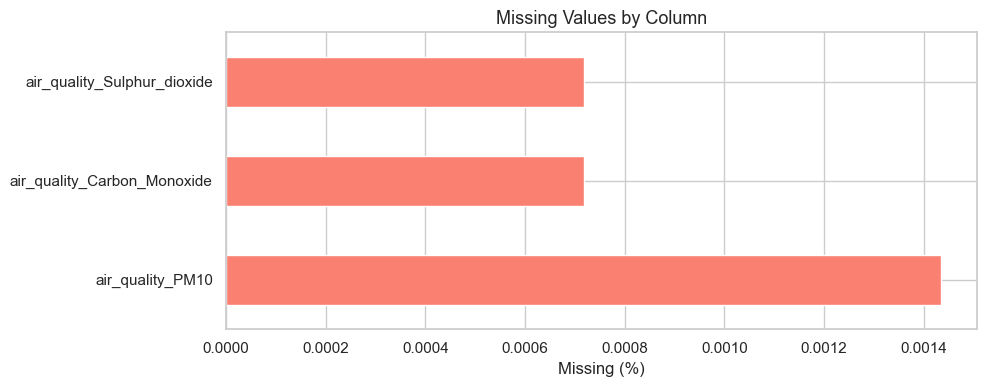

After cleaning — 139,363 rows x 28 columns


In [4]:
# -- Drop redundant unit-duplicate and irrelevant columns ----------------------
# Imperial variants are exact linear transforms of their metric equivalents;
# keeping both inflates correlations and wastes memory/scaling budget
drop_redundant = [
    'temperature_fahrenheit',  # = celsius * 1.8 + 32
    'feels_like_fahrenheit',   # = feels_like_celsius * 1.8 + 32
    'wind_mph',                # = wind_kph * 0.621
    'gust_mph',                # = gust_kph * 0.621
    'pressure_in',             # = pressure_mb * 0.02953
    'precip_in',               # = precip_mm * 0.03937
    'visibility_miles',        # = visibility_km * 0.621
    'last_updated_epoch',      # redundant integer timestamp
    'sunrise', 'sunset',       # string fields not used in models
    'moonrise', 'moonset',     # irrelevant to temperature forecasting
    'moon_phase',              # irrelevant to temperature forecasting
]
drop_redundant = [c for c in drop_redundant if c in df.columns]
df.drop(columns=drop_redundant, inplace=True)
print(f'Dropped {len(drop_redundant)} redundant/irrelevant columns: {drop_redundant}')

# -- Replace sentinel missing-data values with NaN ----------------------------
# Air quality sensors encode failures as -9999; negative readings are physically
# impossible for most metrics, so treat them as missing rather than real values
aq_cols_present = [c for c in df.columns if c.startswith('air_quality_')]
for col in aq_cols_present:
    n_bad = (df[col] < 0).sum()
    if n_bad:
        df[col] = df[col].where(df[col] >= 0, np.nan)
        print(f'  Replaced {n_bad:,} sentinel values in {col}')

# ── Missing value analysis ─────────────────────────────────────────────────────
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct':   df.isnull().mean() * 100,
    'dtype':         df.dtypes
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)

print(f'Columns with missing data: {len(missing)}')
if len(missing) > 0:
    display(missing)
else:
    print('  No missing values found.')

# Visualise missing data
if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing) * 0.4)))
    missing['missing_pct'].plot.barh(ax=ax, color='salmon', edgecolor='white')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Values by Column')
    plt.tight_layout()
    plt.savefig('plots/missing_values.png', bbox_inches='tight')
    plt.show()

# ── Handle missing values ──────────────────────────────────────────────────────
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in num_cols:
    pct = df[col].isnull().mean()
    if 0 < pct <= 0.30:
        df[col].fillna(df[col].median(), inplace=True)
    elif pct > 0.30:
        df.drop(columns=[col], inplace=True)
        print(f'  Dropped {col} ({pct*100:.1f}% missing)')

for col in cat_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

# Refresh column lists after potential drops
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'After cleaning — {df.shape[0]:,} rows x {df.shape[1]} columns')

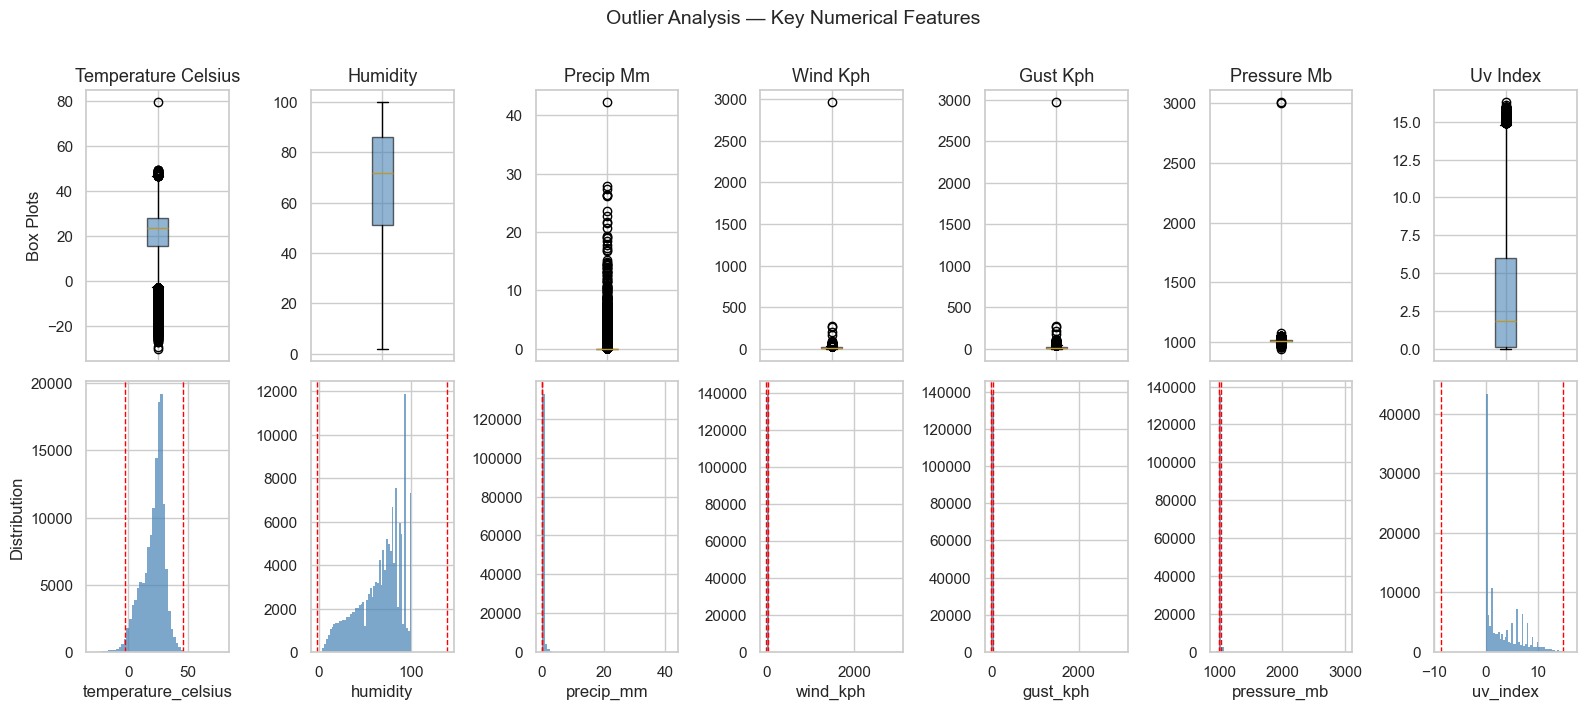


Outlier Summary:
                      lower    upper  n_outliers    pct
temperature_celsius  -2.750   46.450    2207.000  1.580
humidity             -1.500  138.500       0.000  0.000
precip_mm            -0.030    0.050   28291.000 20.300
wind_kph            -11.150   34.850    2397.000  1.720
gust_kph            -10.650   44.950    3790.000  2.720
pressure_mb         998.000 1030.000    4139.000  2.970
uv_index             -8.750   14.850     222.000  0.160

Outliers capped via Winsorization. Shape: (139363, 28)


In [5]:
# ── Outlier detection (IQR) ────────────────────────────────────────────────────
key_num = ['temperature_celsius','humidity','precip_mm','wind_kph','gust_kph','pressure_mb','uv_index']
key_num = [c for c in key_num if c in df.columns]

fig, axes = plt.subplots(2, len(key_num), figsize=(16, 7))
outlier_summary = {}

for i, col in enumerate(key_num):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_summary[col] = {'lower': lo, 'upper': hi, 'n_outliers': n_out,
                            'pct': round(n_out / len(df) * 100, 2)}
    # Box plot
    axes[0, i].boxplot(df[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[0, i].set_title(col.replace('_', ' ').title())
    axes[0, i].set_xticklabels([])
    # Distribution
    axes[1, i].hist(df[col].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='none')
    axes[1, i].axvline(lo, color='red', linestyle='--', linewidth=1, label='IQR bounds')
    axes[1, i].axvline(hi, color='red', linestyle='--', linewidth=1)
    axes[1, i].set_xlabel(col)

axes[0, 0].set_ylabel('Box Plots')
axes[1, 0].set_ylabel('Distribution')
plt.suptitle('Outlier Analysis — Key Numerical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plots/outlier_analysis.png', bbox_inches='tight')
plt.show()

print('\nOutlier Summary:')
print(pd.DataFrame(outlier_summary).T.to_string())

# Cap outliers at IQR bounds (Winsorization) for the clean copy
df_clean = df.copy()
for col, bounds in outlier_summary.items():
    df_clean[col] = df_clean[col].clip(bounds['lower'], bounds['upper'])
print(f'\nOutliers capped via Winsorization. Shape: {df_clean.shape}')

In [6]:
# ── Feature engineering & normalisation ────────────────────────────────────────
# Parse datetime
df_clean['last_updated'] = pd.to_datetime(df_clean['last_updated'], errors='coerce')
df_clean = df_clean.dropna(subset=['last_updated'])

df_clean['year']        = df_clean['last_updated'].dt.year
df_clean['month']       = df_clean['last_updated'].dt.month
df_clean['day']         = df_clean['last_updated'].dt.day
df_clean['dayofweek']   = df_clean['last_updated'].dt.dayofweek
df_clean['hour']        = df_clean['last_updated'].dt.hour
df_clean['quarter']     = df_clean['last_updated'].dt.quarter
df_clean['season']      = df_clean['month'].map({
    12:'Winter',1:'Winter',2:'Winter',
    3:'Spring',4:'Spring',5:'Spring',
    6:'Summer',7:'Summer',8:'Summer',
    9:'Autumn',10:'Autumn',11:'Autumn'})

# Hemisphere-aware season
if 'latitude' in df_clean.columns:
    mask_sh = df_clean['latitude'] < 0   # Southern Hemisphere
    flip = {'Winter':'Summer','Summer':'Winter','Spring':'Autumn','Autumn':'Spring'}
    df_clean.loc[mask_sh, 'season'] = df_clean.loc[mask_sh, 'season'].map(flip)

# Derived metrics
if 'temperature_celsius' in df_clean.columns and 'humidity' in df_clean.columns:
    # Apparent temperature (Steadman)
    T  = df_clean['temperature_celsius']
    H  = df_clean['humidity']
    df_clean['apparent_temp'] = -8.78469475556 + \
        1.61139411 * T + 2.33854883889 * H/100 - \
        0.14611605 * T * H/100 - 0.012308094 * T**2 - \
        0.0164248277778 * (H/100)**2 + \
        0.002211732 * T**2 * H/100 + \
        0.00072546 * T * (H/100)**2 - \
        0.000003582 * T**2 * (H/100)**2

# Add continent if not present
if 'continent' not in df_clean.columns and 'country' in df_clean.columns:
    cont_map = {
        'United States':'Americas','Canada':'Americas','Mexico':'Americas',
        'Brazil':'Americas','Argentina':'Americas','Colombia':'Americas',
        'United Kingdom':'Europe','Germany':'Europe','France':'Europe',
        'Spain':'Europe','Italy':'Europe','Russia':'Europe',
        'China':'Asia','India':'Asia','Japan':'Asia','Saudi Arabia':'Asia',
        'UAE':'Asia','Thailand':'Asia','Indonesia':'Asia',
        'Australia':'Oceania','New Zealand':'Oceania',
        'South Africa':'Africa','Egypt':'Africa','Nigeria':'Africa',
        'Kenya':'Africa','Ethiopia':'Africa'
    }
    df_clean['continent'] = df_clean['country'].map(cont_map).fillna('Other')

# Normalise numerical columns
scaler = StandardScaler()
feat_for_scale = [c for c in num_cols if c in df_clean.columns and
                  c not in ('last_updated_epoch',)]
df_scaled = df_clean.copy()
df_scaled[feat_for_scale] = scaler.fit_transform(df_clean[feat_for_scale])

print(f'Cleaned dataset: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns')
print(f'New features added: year, month, day, dayofweek, hour, quarter, season, apparent_temp')
df_clean[['last_updated','temperature_celsius','humidity','season','apparent_temp']].head(4)

Cleaned dataset: 139,363 rows x 37 columns
New features added: year, month, day, dayofweek, hour, quarter, season, apparent_temp


,last_updated,temperature_celsius,humidity,season,apparent_temp
0,2024-05-16 13:15:00,26.600,24,Spring,25.374
1,2024-05-16 10:45:00,19.000,94,Spring,17.724
2,2024-05-16 09:45:00,23.000,29,Spring,21.809
3,2024-05-16 10:45:00,6.300,61,Spring,1.793


---
## 3. Exploratory Data Analysis (EDA) <a id='eda'></a>

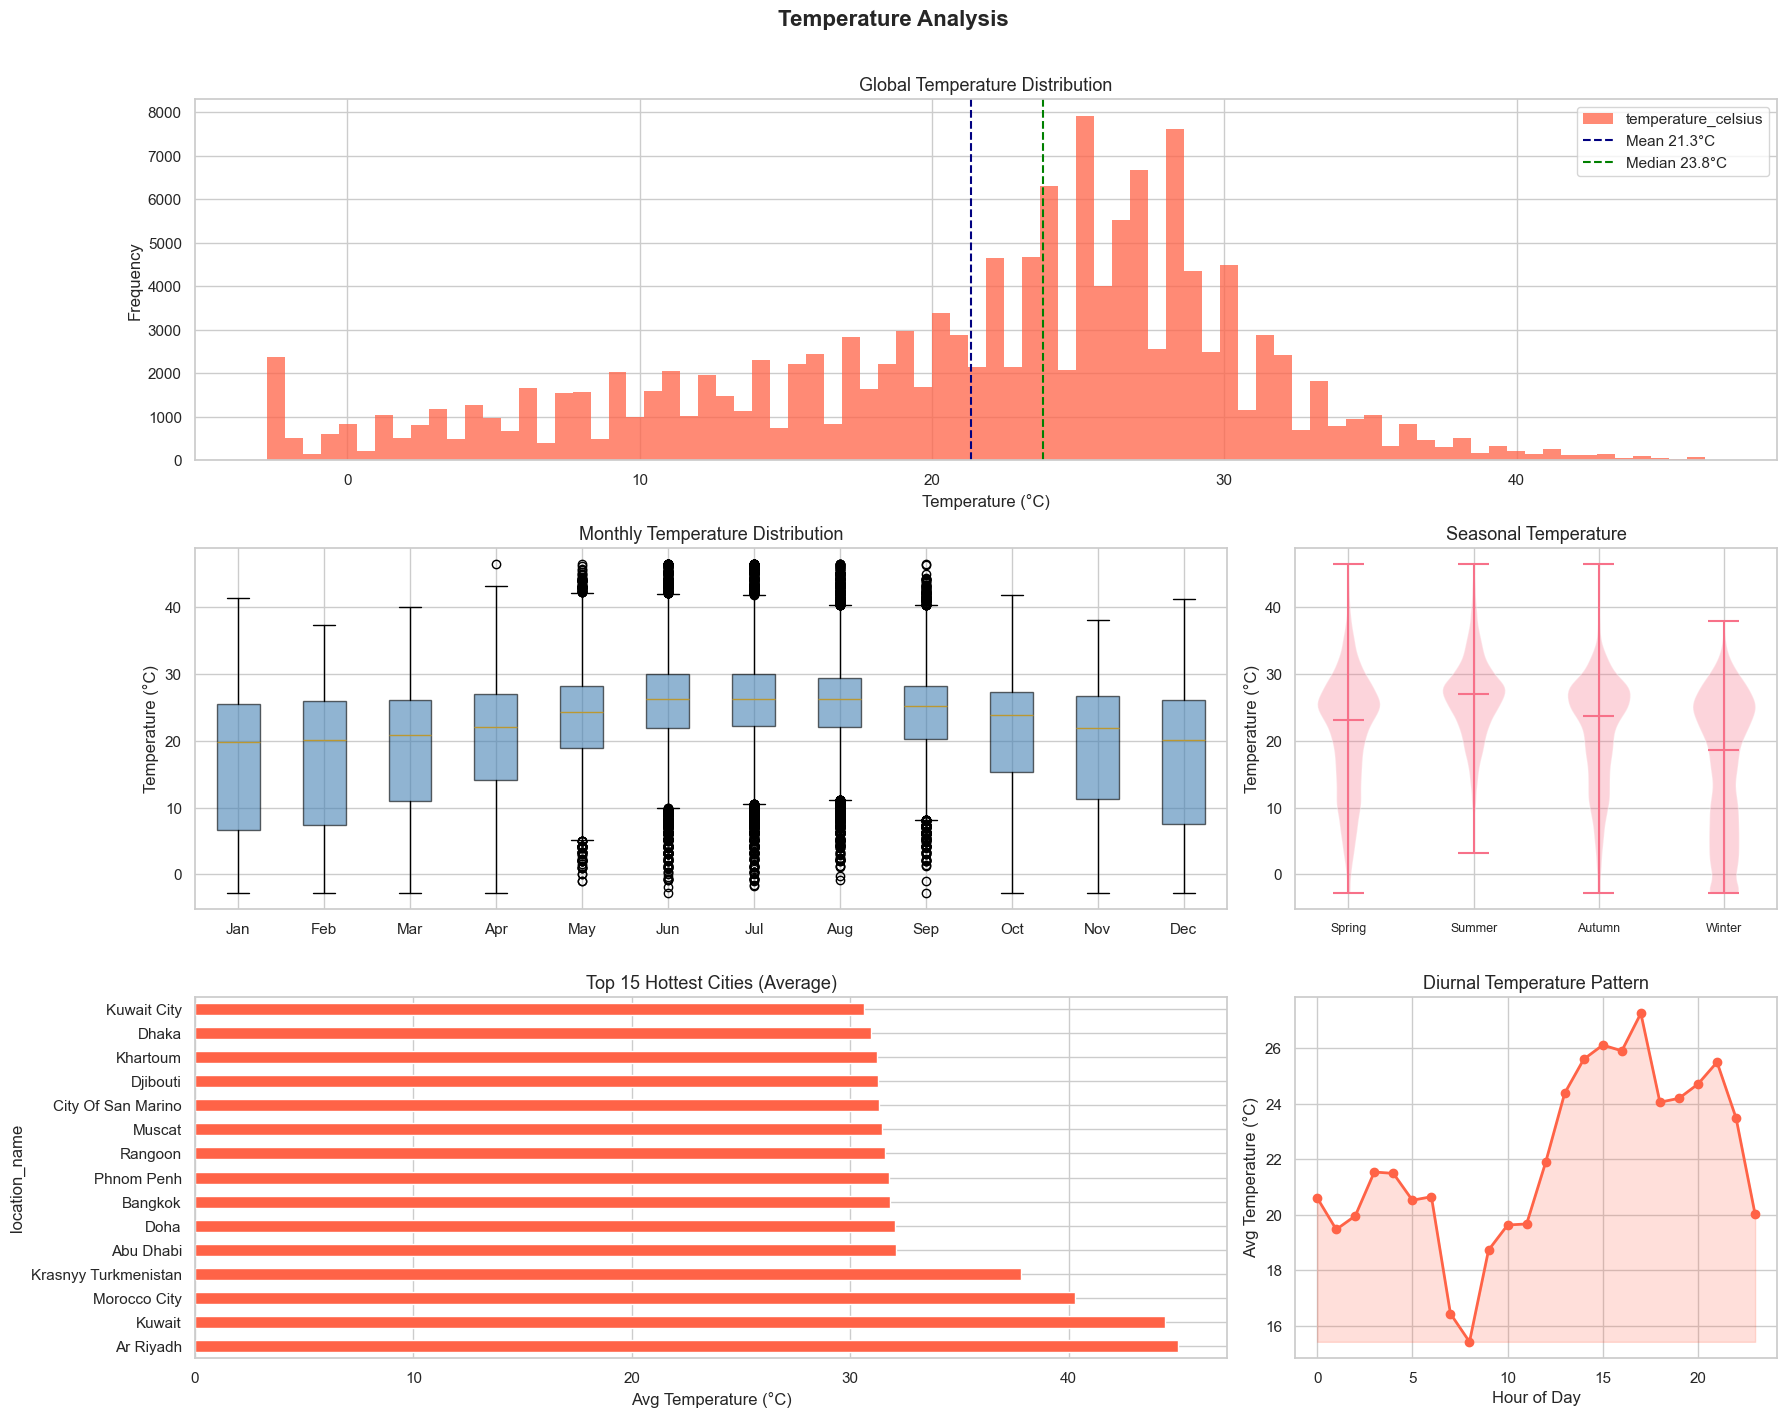

In [7]:
# ── Temperature analysis ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig)

# 1. Global temperature distribution
ax1 = fig.add_subplot(gs[0, :])
df_clean['temperature_celsius'].plot.hist(bins=80, ax=ax1, color='tomato', alpha=0.75, edgecolor='none')
ax1.axvline(df_clean['temperature_celsius'].mean(), color='navy', linestyle='--', label=f'Mean {df_clean["temperature_celsius"].mean():.1f}°C')
ax1.axvline(df_clean['temperature_celsius'].median(), color='green', linestyle='--', label=f'Median {df_clean["temperature_celsius"].median():.1f}°C')
ax1.set_xlabel('Temperature (°C)')
ax1.set_title('Global Temperature Distribution')
ax1.legend()

# 2. Monthly temperature (box)
ax2 = fig.add_subplot(gs[1, :2])
month_temp = [df_clean[df_clean['month'] == m]['temperature_celsius'].dropna().values
              for m in range(1, 13)]
ax2.boxplot(month_temp, labels=[datetime(2000, m, 1).strftime('%b') for m in range(1, 13)],
            patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6))
ax2.set_ylabel('Temperature (°C)')
ax2.set_title('Monthly Temperature Distribution')

# 3. Seasonal violin
ax3 = fig.add_subplot(gs[1, 2])
if 'season' in df_clean.columns:
    seas_order = ['Spring','Summer','Autumn','Winter']
    seas_data = [df_clean[df_clean['season'] == s]['temperature_celsius'].dropna().values
                 for s in seas_order if s in df_clean['season'].values]
    if seas_data:
        parts = ax3.violinplot(seas_data, showmedians=True)
        ax3.set_xticks(range(1, len(seas_order) + 1))
        ax3.set_xticklabels(seas_order, fontsize=9)
        ax3.set_ylabel('Temperature (°C)')
        ax3.set_title('Seasonal Temperature')

# 4. Top 15 hottest cities
ax4 = fig.add_subplot(gs[2, :2])
if 'location_name' in df_clean.columns:
    city_temp = df_clean.groupby('location_name')['temperature_celsius'].mean().nlargest(15)
    city_temp.plot.barh(ax=ax4, color='tomato', edgecolor='white')
    ax4.set_xlabel('Avg Temperature (°C)')
    ax4.set_title('Top 15 Hottest Cities (Average)')

# 5. Hourly temperature pattern
ax5 = fig.add_subplot(gs[2, 2])
if 'hour' in df_clean.columns:
    hourly = df_clean.groupby('hour')['temperature_celsius'].mean()
    ax5.plot(hourly.index, hourly.values, marker='o', color='tomato', linewidth=2)
    ax5.fill_between(hourly.index, hourly.values, hourly.min(), alpha=0.2, color='tomato')
    ax5.set_xlabel('Hour of Day')
    ax5.set_ylabel('Avg Temperature (°C)')
    ax5.set_title('Diurnal Temperature Pattern')

plt.suptitle('Temperature Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/temperature_analysis.png', bbox_inches='tight')
plt.show()

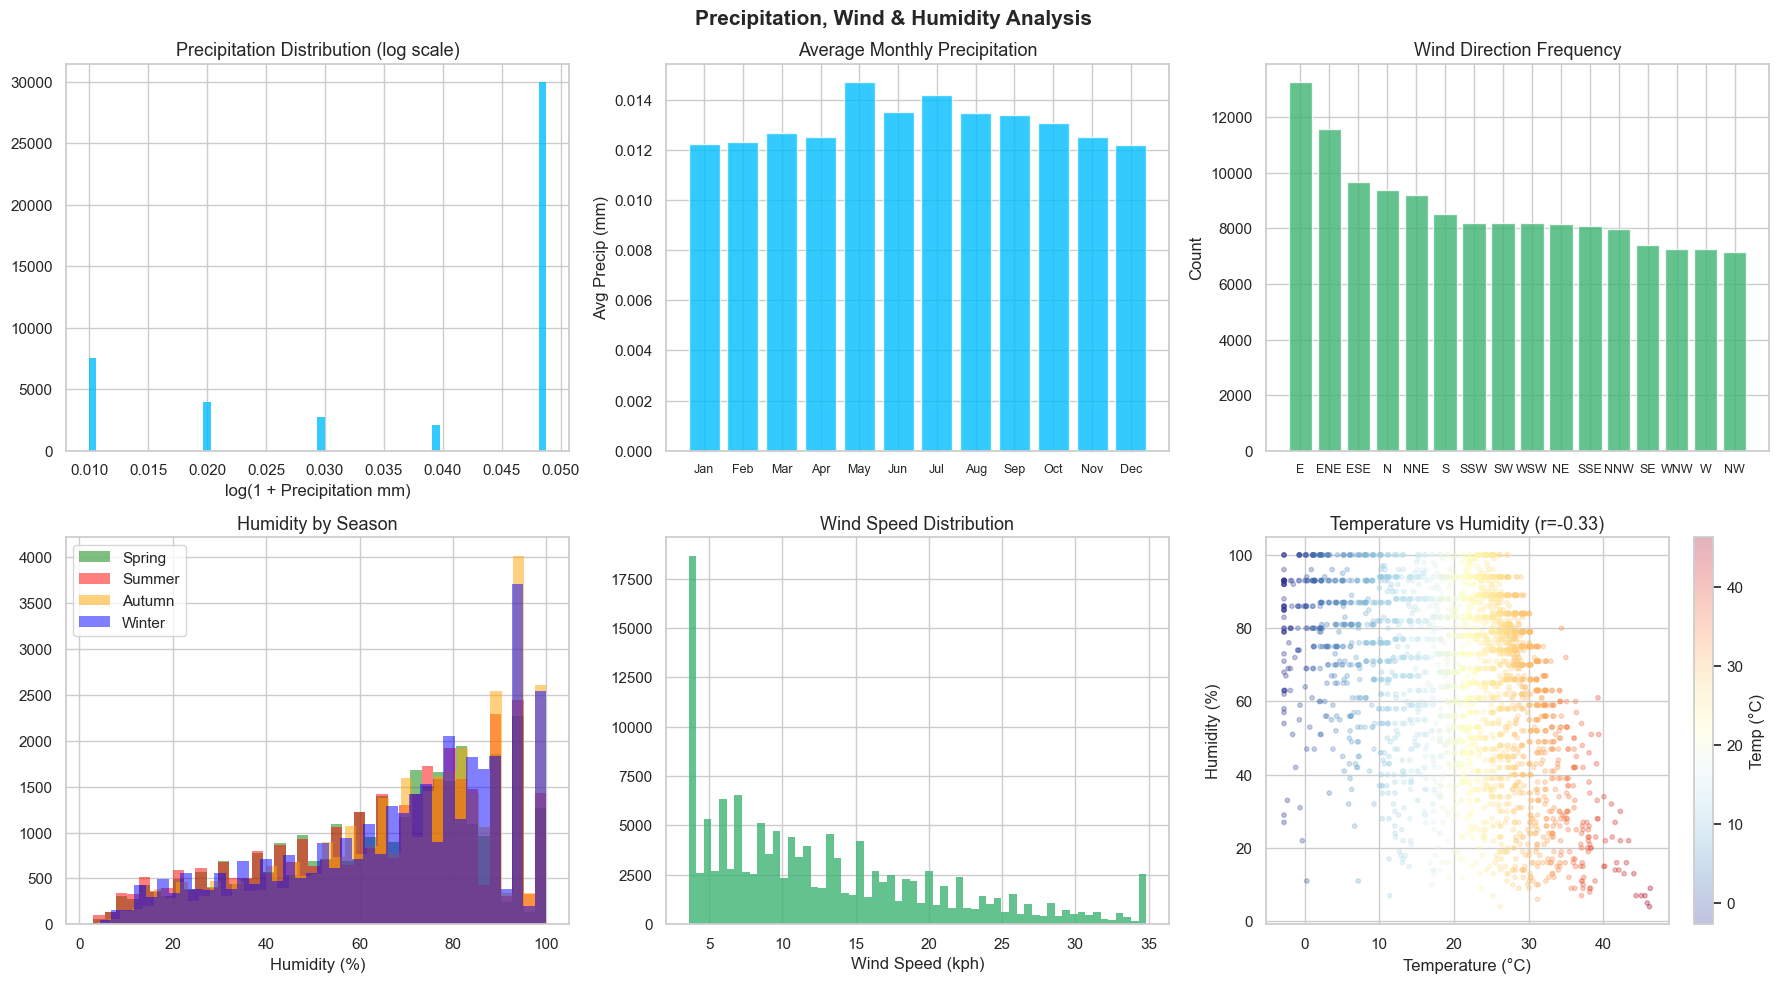

In [8]:
# ── Precipitation, wind & humidity ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Precip distribution (log scale)
precip_vals = df_clean['precip_mm'][df_clean['precip_mm'] > 0].dropna() if 'precip_mm' in df_clean.columns else pd.Series(dtype=float)
if len(precip_vals):
    axes[0, 0].hist(np.log1p(precip_vals), bins=60, color='deepskyblue', alpha=0.8, edgecolor='none')
    axes[0, 0].set_xlabel('log(1 + Precipitation mm)')
    axes[0, 0].set_title('Precipitation Distribution (log scale)')

# Monthly precipitation
if 'precip_mm' in df_clean.columns and 'month' in df_clean.columns:
    monthly_precip = df_clean.groupby('month')['precip_mm'].mean()
    axes[0, 1].bar(monthly_precip.index, monthly_precip.values,
                   color='deepskyblue', alpha=0.8, edgecolor='white')
    axes[0, 1].set_xticks(range(1, 13))
    axes[0, 1].set_xticklabels([datetime(2000, m, 1).strftime('%b') for m in range(1, 13)], fontsize=9)
    axes[0, 1].set_ylabel('Avg Precip (mm)')
    axes[0, 1].set_title('Average Monthly Precipitation')

# Wind direction rose (simplified)
if 'wind_direction' in df_clean.columns:
    wind_dir = df_clean['wind_direction'].value_counts()
    axes[0, 2].bar(range(len(wind_dir)), wind_dir.values, color='mediumseagreen', alpha=0.8)
    axes[0, 2].set_xticks(range(len(wind_dir)))
    axes[0, 2].set_xticklabels(wind_dir.index, fontsize=9)
    axes[0, 2].set_ylabel('Count')
    axes[0, 2].set_title('Wind Direction Frequency')

# Humidity distribution by season
if 'humidity' in df_clean.columns and 'season' in df_clean.columns:
    for s, color in zip(['Spring','Summer','Autumn','Winter'],
                        ['green','red','orange','blue']):
        sub = df_clean[df_clean['season'] == s]['humidity'].dropna()
        if len(sub):
            axes[1, 0].hist(sub, bins=40, alpha=0.5, color=color, label=s, edgecolor='none')
    axes[1, 0].set_xlabel('Humidity (%)')
    axes[1, 0].set_title('Humidity by Season')
    axes[1, 0].legend()

# Wind speed distribution
if 'wind_kph' in df_clean.columns:
    axes[1, 1].hist(df_clean['wind_kph'].dropna(), bins=60, color='mediumseagreen', alpha=0.8, edgecolor='none')
    axes[1, 1].set_xlabel('Wind Speed (kph)')
    axes[1, 1].set_title('Wind Speed Distribution')

# Temp vs Humidity scatter
if all(c in df_clean.columns for c in ['temperature_celsius','humidity']):
    sample = df_clean.sample(min(3000, len(df_clean)), random_state=42)
    sc = axes[1, 2].scatter(sample['temperature_celsius'], sample['humidity'],
                             alpha=0.3, s=10, c=sample['temperature_celsius'],
                             cmap='RdYlBu_r')
    plt.colorbar(sc, ax=axes[1, 2], label='Temp (°C)')
    axes[1, 2].set_xlabel('Temperature (°C)')
    axes[1, 2].set_ylabel('Humidity (%)')
    axes[1, 2].set_title('Temperature vs Humidity')
    r, p = stats.pearsonr(sample['temperature_celsius'], sample['humidity'])
    axes[1, 2].set_title(f'Temperature vs Humidity (r={r:.2f})')

plt.suptitle('Precipitation, Wind & Humidity Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/precipitation_wind_humidity.png', bbox_inches='tight')
plt.show()

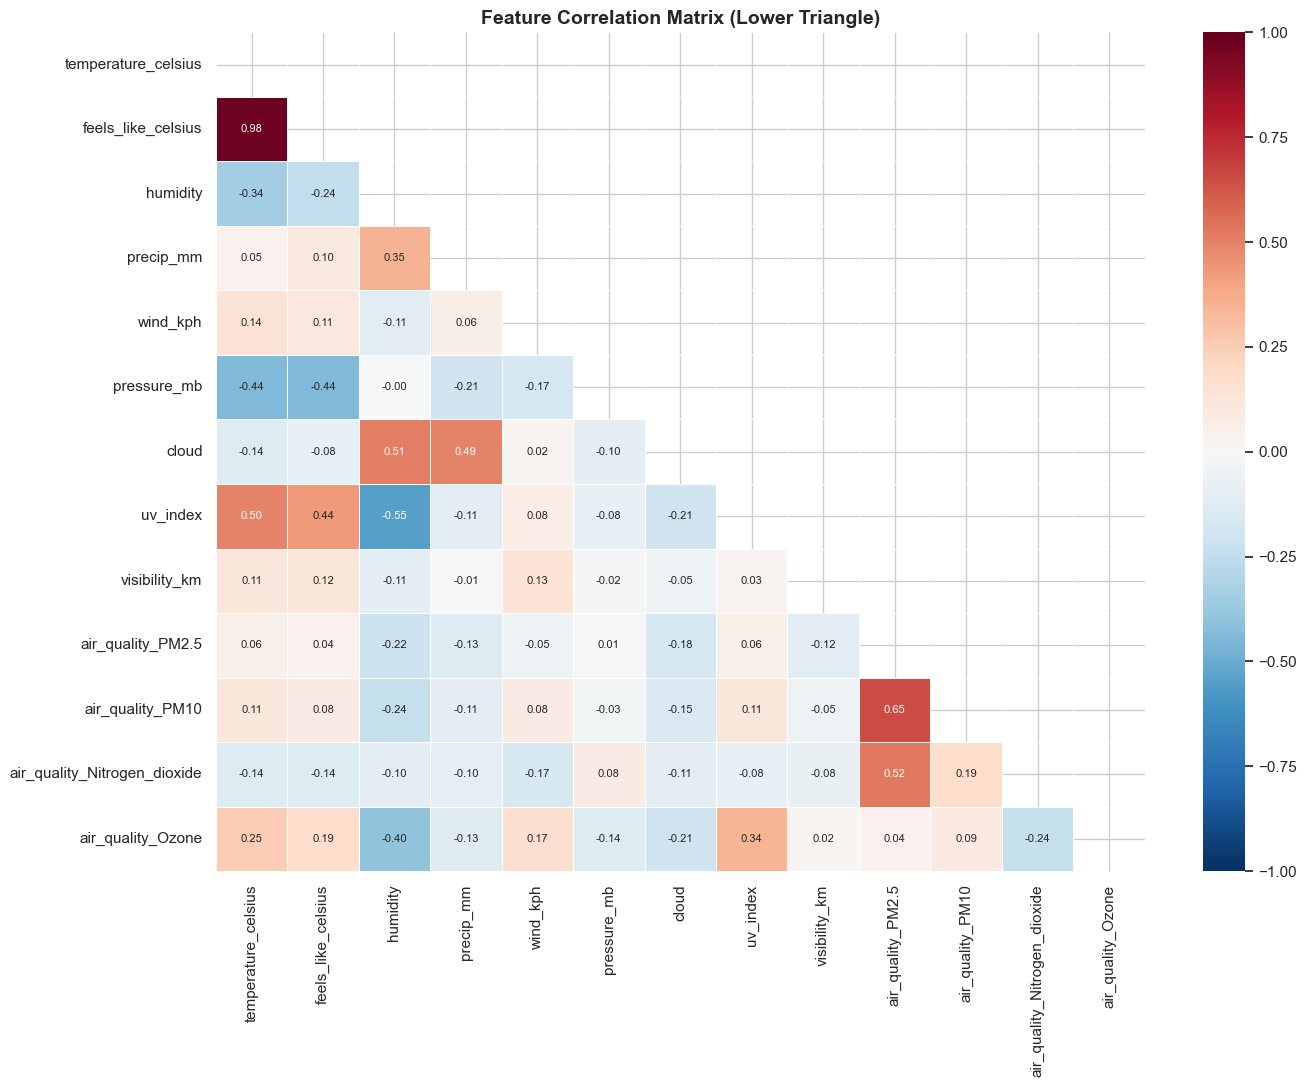

Top correlations with temperature_celsius:
feels_like_celsius              0.979
uv_index                        0.497
pressure_mb                    -0.442
humidity                       -0.344
air_quality_Ozone               0.254
air_quality_Nitrogen_dioxide   -0.139
wind_kph                        0.135
cloud                          -0.135


In [9]:
# ── Correlation heatmap ────────────────────────────────────────────────────────
corr_cols = ['temperature_celsius','feels_like_celsius','humidity','precip_mm',
             'wind_kph','pressure_mb','cloud','uv_index','visibility_km',
             'air_quality_PM2.5','air_quality_PM10',
             'air_quality_Nitrogen_dioxide','air_quality_Ozone']
corr_cols = [c for c in corr_cols if c in df_clean.columns]

corr_matrix = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix (Lower Triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Top correlations with temperature
if 'temperature_celsius' in corr_matrix.columns:
    top_corr = corr_matrix['temperature_celsius'].drop('temperature_celsius').abs().nlargest(8)
    print('Top correlations with temperature_celsius:')
    print(corr_matrix['temperature_celsius'][top_corr.index].to_string())

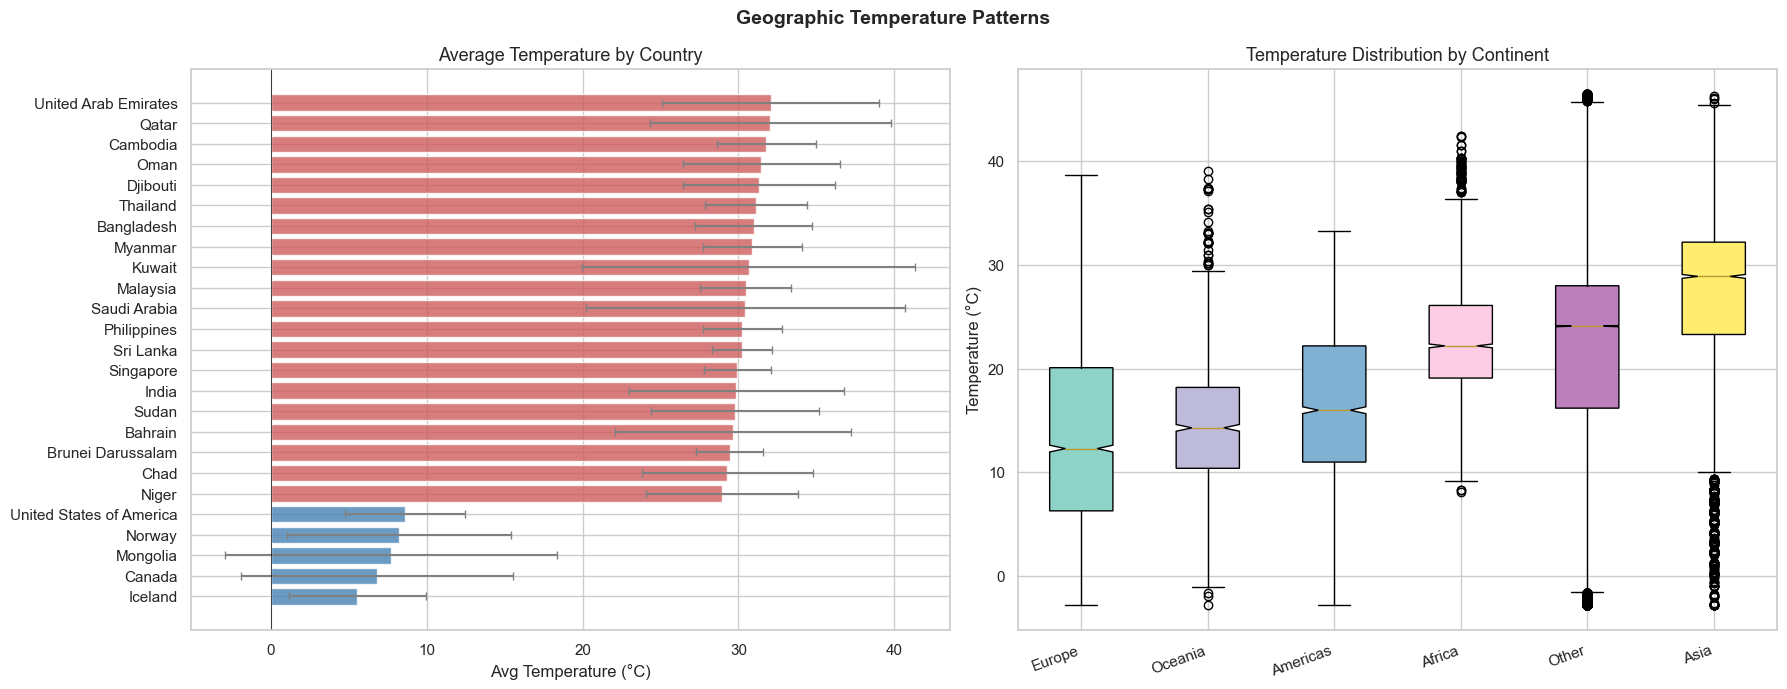

In [10]:
# ── Country / Continental patterns ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Temperature by country (top 20 + bottom 5)
if 'country' in df_clean.columns:
    country_stats = df_clean.groupby('country')['temperature_celsius'].agg(['mean','std','count'])
    country_stats = country_stats[country_stats['count'] >= 20].sort_values('mean')
    
    # Top 20 + bottom 5
    show = pd.concat([country_stats.head(5), country_stats.tail(20)])
    colors = ['#4682B4'] * 5 + ['#CD5C5C'] * min(20, len(country_stats) - 5)
    axes[0].barh(show.index, show['mean'], color=colors[:len(show)],
                 xerr=show['std'], capsize=3, alpha=0.8, ecolor='grey')
    axes[0].axvline(0, color='black', linestyle='-', linewidth=0.5)
    axes[0].set_xlabel('Avg Temperature (°C)')
    axes[0].set_title('Average Temperature by Country')

# Temperature by continent
if 'continent' in df_clean.columns:
    cont_temp = df_clean.groupby('continent')['temperature_celsius']
    cont_data = [cont_temp.get_group(c).dropna().values
                 for c in df_clean['continent'].unique() if c in cont_temp.groups]
    cont_labels = [c for c in df_clean['continent'].unique() if c in cont_temp.groups]
    order = sorted(zip([np.median(d) for d in cont_data], cont_labels, cont_data),
                   key=lambda x: x[0])
    cont_data_sorted = [x[2] for x in order]
    cont_labels_sorted = [x[1] for x in order]
    bp = axes[1].boxplot(cont_data_sorted, labels=cont_labels_sorted,
                         patch_artist=True, notch=True)
    colors_box = plt.cm.Set3(np.linspace(0, 1, len(cont_labels_sorted)))
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
    axes[1].set_ylabel('Temperature (°C)')
    axes[1].set_title('Temperature Distribution by Continent')
    plt.setp(axes[1].get_xticklabels(), rotation=20, ha='right')

plt.suptitle('Geographic Temperature Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/geographic_patterns.png', bbox_inches='tight')
plt.show()

---
## 4. Advanced EDA: Anomaly Detection <a id='anomaly'></a>

Z-score anomalies (|z|>3): 0 (0.00%)
IQR anomalies (3×IQR):     0 (0.00%)


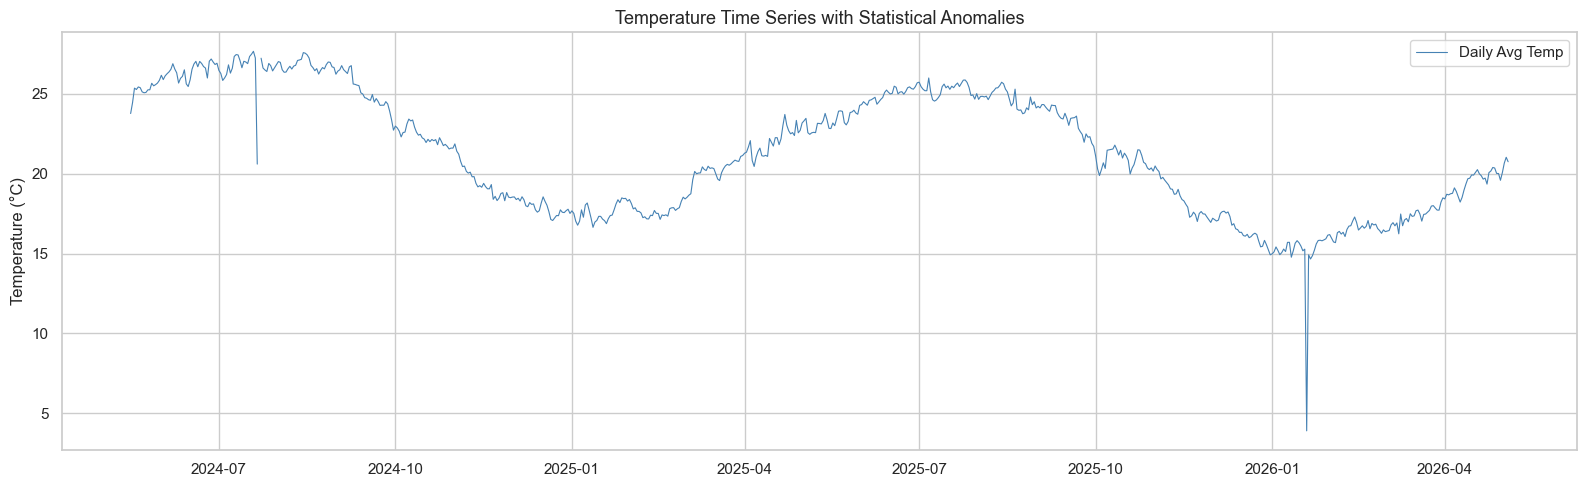

In [11]:
# ── Statistical anomaly detection (Z-score & IQR) ─────────────────────────────
anomaly_cols = ['temperature_celsius','humidity','precip_mm','wind_kph','pressure_mb']
anomaly_cols = [c for c in anomaly_cols if c in df_clean.columns]
df_anom = df_clean[anomaly_cols + ['last_updated']].copy().dropna()

# Z-score method (|z| > 3)
z_scores = np.abs(stats.zscore(df_anom[anomaly_cols]))
df_anom['zscore_anomaly'] = (z_scores > 3).any(axis=1)

# IQR method
iqr_flags = pd.Series(False, index=df_anom.index)
for col in anomaly_cols:
    q1, q3 = df_anom[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    iqr_flags |= (df_anom[col] < q1 - 3 * iqr) | (df_anom[col] > q3 + 3 * iqr)
df_anom['iqr_anomaly'] = iqr_flags

print(f'Z-score anomalies (|z|>3): {df_anom["zscore_anomaly"].sum():,} ({df_anom["zscore_anomaly"].mean()*100:.2f}%)')
print(f'IQR anomalies (3×IQR):     {df_anom["iqr_anomaly"].sum():,} ({df_anom["iqr_anomaly"].mean()*100:.2f}%)')

# Visualise anomalies on temperature time series
ts_anom = df_anom.set_index('last_updated')['temperature_celsius'].resample('D').mean()
z_daily = df_anom[df_anom['zscore_anomaly']].set_index('last_updated')['temperature_celsius']

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(ts_anom.index, ts_anom.values, color='steelblue', linewidth=0.8, label='Daily Avg Temp')
if len(z_daily):
    ax.scatter(z_daily.index, z_daily.values, color='red', s=20, zorder=5,
               alpha=0.7, label=f'Z-score Anomaly ({len(z_daily):,})')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Temperature Time Series with Statistical Anomalies')
ax.legend()
plt.tight_layout()
plt.savefig('plots/statistical_anomalies.png', bbox_inches='tight')
plt.show()

Isolation Forest anomalies: 4,181 (3.00%)
LOF anomalies:              4,181 (3.00%)
Both methods agree:         481 (0.35%)


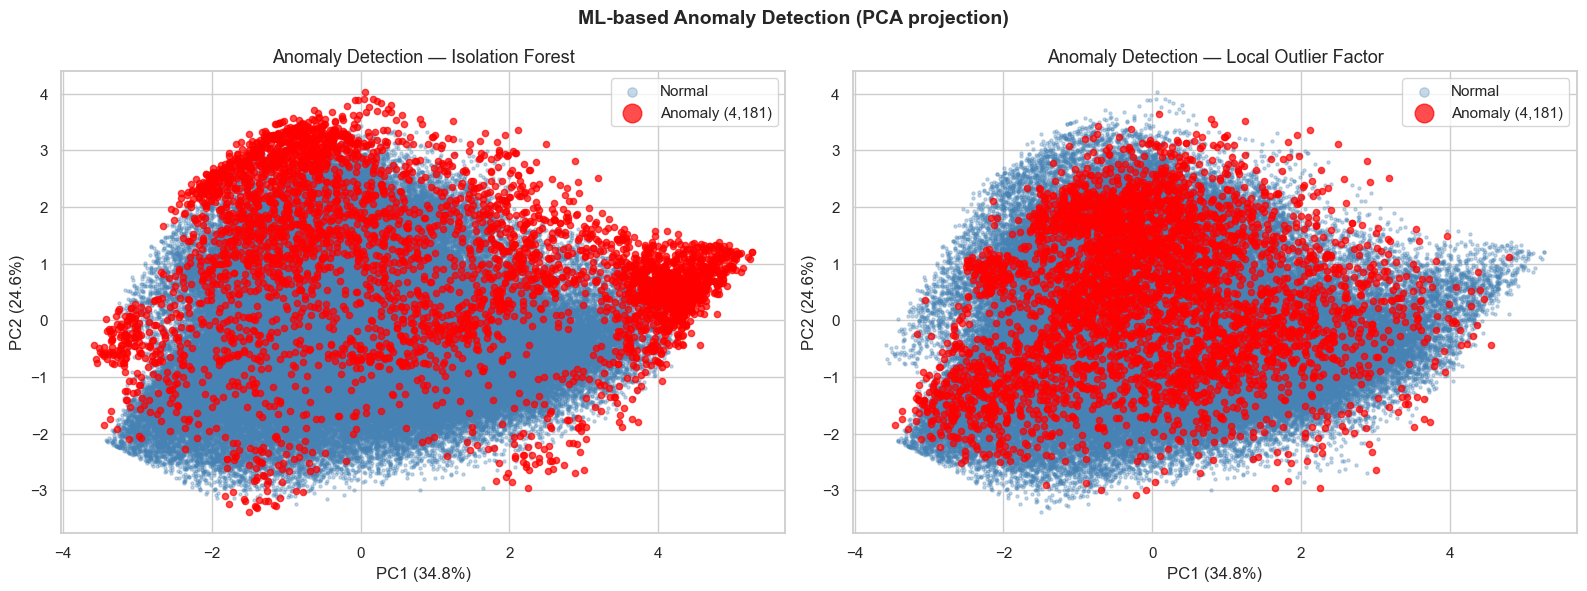


Anomaly Profile (consensus anomalies):
                     Normal_mean  Anomaly_mean   delta
temperature_celsius       21.343        19.400  -1.943
humidity                  66.747        54.665 -12.081
precip_mm                  0.013         0.031   0.018
wind_kph                  12.723        21.905   9.183
pressure_mb             1014.067      1010.237  -3.830
uv_index                   3.283         5.376   2.093


In [12]:
# ── ML anomaly detection: Isolation Forest & LOF ─────────────────────────────
features_for_anomaly = ['temperature_celsius','humidity','precip_mm',
                         'wind_kph','pressure_mb','uv_index']
features_for_anomaly = [c for c in features_for_anomaly if c in df_clean.columns]

X_anom = df_clean[features_for_anomaly].dropna()
X_anom_scaled = StandardScaler().fit_transform(X_anom)

# Isolation Forest
iso = IsolationForest(n_estimators=200, contamination=0.03, random_state=42, n_jobs=-1)
iso_labels = iso.fit_predict(X_anom_scaled)   # -1 = anomaly, 1 = normal
iso_scores = iso.score_samples(X_anom_scaled)  # lower = more anomalous

# Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=30, contamination=0.03, n_jobs=-1)
lof_labels = lof.fit_predict(X_anom_scaled)
lof_scores = -lof.negative_outlier_factor_  # higher = more anomalous

X_anom_df = X_anom.copy()
X_anom_df['iso_label']   = iso_labels
X_anom_df['lof_label']   = lof_labels
X_anom_df['iso_score']   = iso_scores
X_anom_df['both_anomaly'] = (iso_labels == -1) & (lof_labels == -1)

print(f'Isolation Forest anomalies: {(iso_labels == -1).sum():,} ({(iso_labels == -1).mean()*100:.2f}%)')
print(f'LOF anomalies:              {(lof_labels == -1).sum():,} ({(lof_labels == -1).mean()*100:.2f}%)')
print(f'Both methods agree:         {X_anom_df["both_anomaly"].sum():,} ({X_anom_df["both_anomaly"].mean()*100:.2f}%)')

# 2-D visualisation via PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_anom_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, labels, title, scores in [
    (axes[0], iso_labels, 'Isolation Forest', iso_scores),
    (axes[1], lof_labels, 'Local Outlier Factor', lof_scores),
]:
    normal_idx  = labels == 1
    anomaly_idx = labels == -1
    ax.scatter(X_2d[normal_idx, 0], X_2d[normal_idx, 1],
               c='steelblue', s=5, alpha=0.3, label='Normal')
    ax.scatter(X_2d[anomaly_idx, 0], X_2d[anomaly_idx, 1],
               c='red', s=20, alpha=0.7, label=f'Anomaly ({anomaly_idx.sum():,})')
    ax.set_title(f'Anomaly Detection — {title}')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.legend(markerscale=3)

plt.suptitle('ML-based Anomaly Detection (PCA projection)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/ml_anomaly_detection.png', bbox_inches='tight')
plt.show()

# Anomaly characteristics
print('\nAnomaly Profile (consensus anomalies):')
consensus = X_anom_df[X_anom_df['both_anomaly']][features_for_anomaly]
normal    = X_anom_df[~X_anom_df['both_anomaly']][features_for_anomaly]
comparison = pd.DataFrame({'Normal_mean': normal.mean(), 'Anomaly_mean': consensus.mean()})
comparison['delta'] = comparison['Anomaly_mean'] - comparison['Normal_mean']
print(comparison.to_string())

---
## 5. Time Series Analysis & Decomposition <a id='timeseries'></a>

Replacing 1 outlier days with interpolated values
Daily time series: 718 days
Date range: 2024-05-16 to 2026-05-04
ADF Test — temperature_celsius:
  Statistic : -1.1133
  p-value   : 0.7097
  Stationary: NO


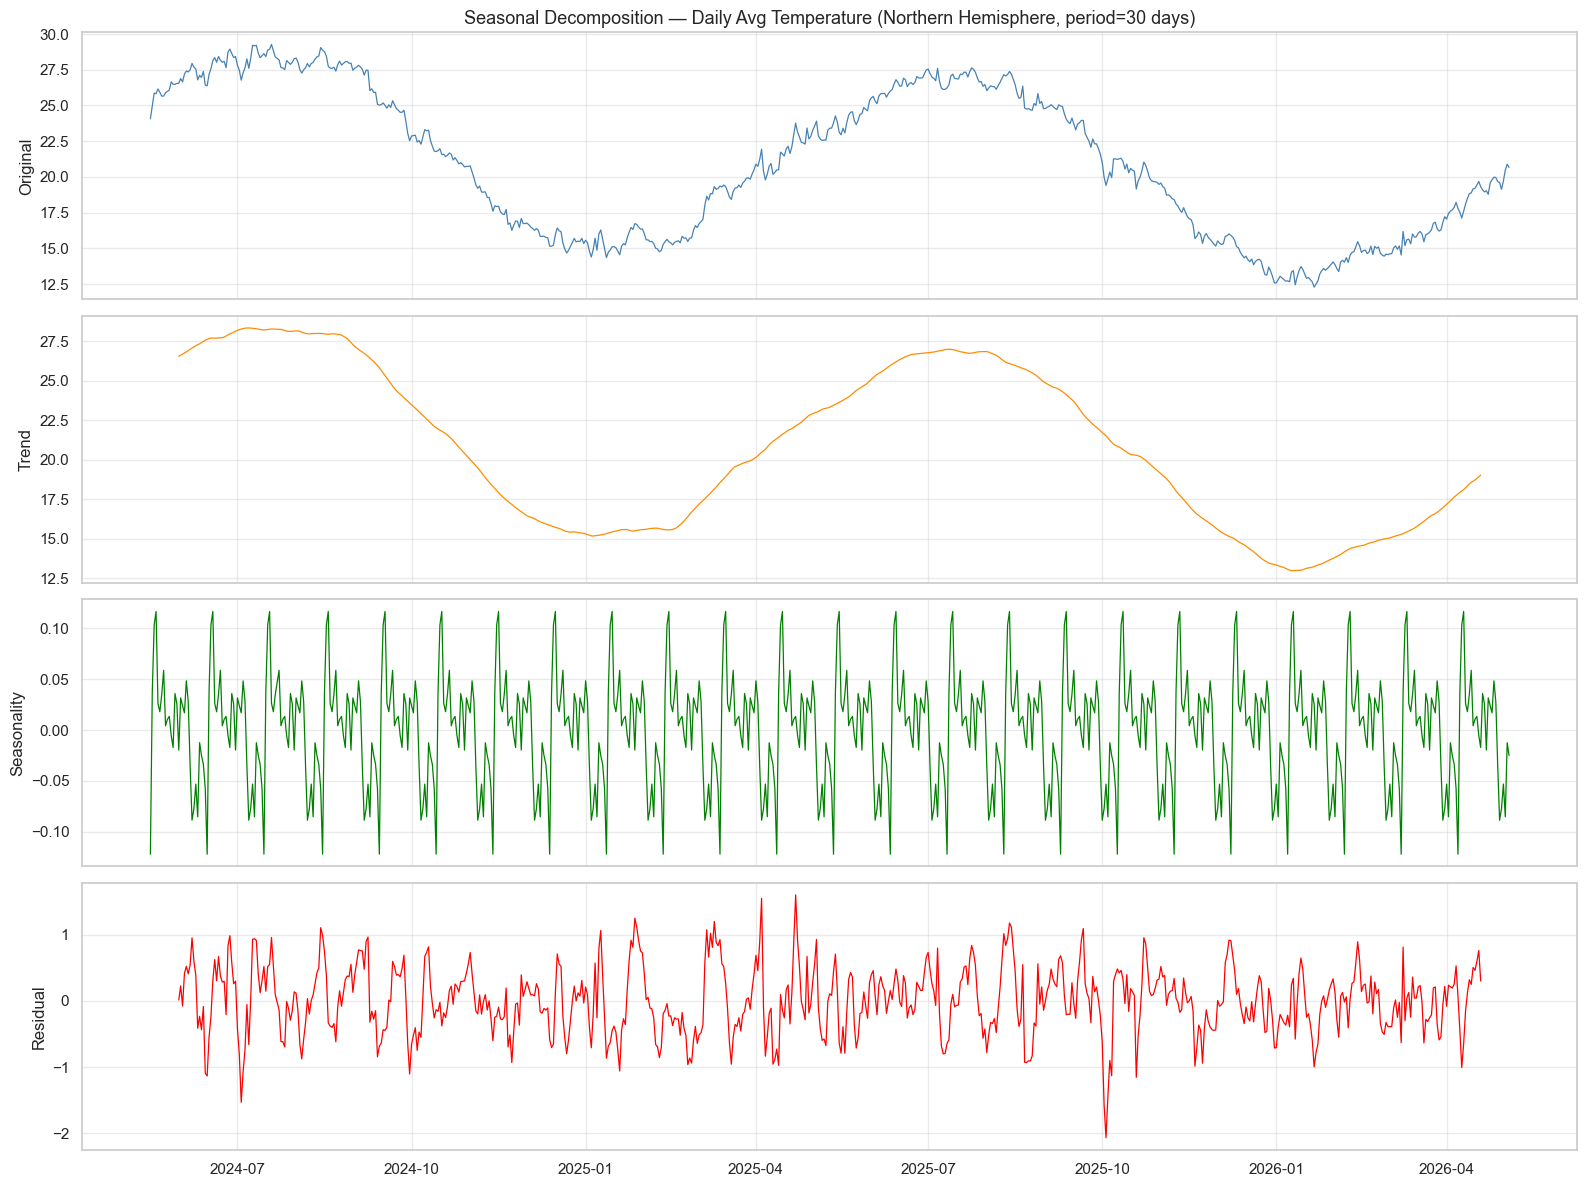

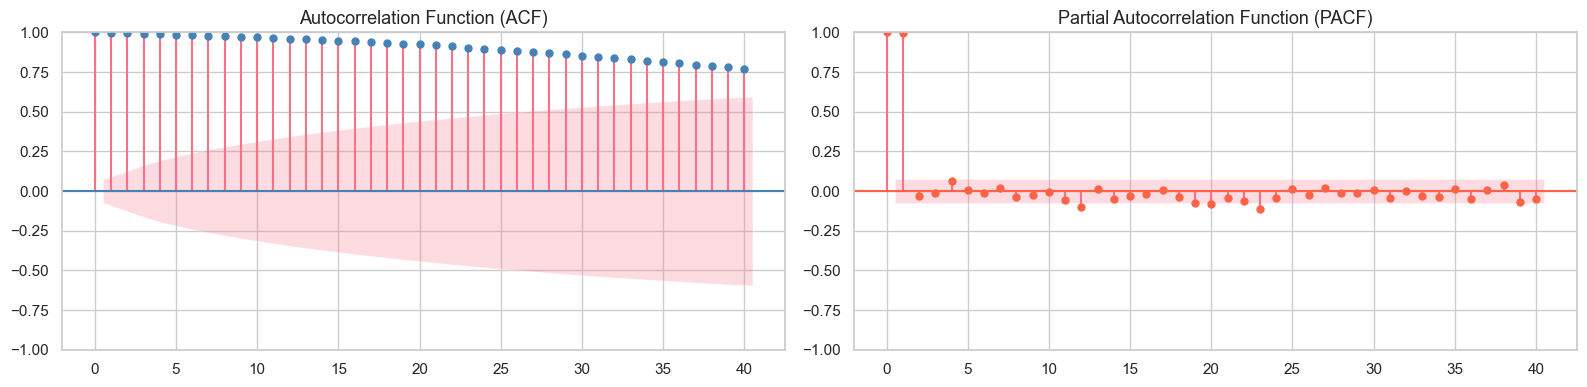

In [13]:
# -- Build daily time series ---------------------------------------------------
# Filter to Northern Hemisphere so annual seasonality isn't cancelled by opposing hemispheres
# (global average of NH summer + SH winter = flat signal, making seasonal models blind)
df_ts_src = df_clean[df_clean['latitude'] > 0] if 'latitude' in df_clean.columns else df_clean
df_ts_raw = df_ts_src.set_index('last_updated')
daily_ts = df_ts_raw.resample('D').agg({
    'temperature_celsius': 'mean',
    'humidity':            'mean',
    'precip_mm':           'sum',
    'wind_kph':            'mean',
    'pressure_mb':         'mean',
}).dropna(subset=['temperature_celsius'])

# Fill short gaps by interpolation
daily_ts = daily_ts.interpolate(method='time', limit=3)
daily_ts = daily_ts.dropna()
# Correct outlier dips/spikes in the daily series (data quality errors skew lag features)
_roll = daily_ts['temperature_celsius'].rolling(14, center=True, min_periods=3)
_med  = _roll.median()
_local_std = _roll.std()
_thresh_std = _local_std.fillna(daily_ts['temperature_celsius'].std()).clip(lower=1.5)
_bad  = abs(daily_ts['temperature_celsius'] - _med) > 3.0 * _thresh_std
if _bad.sum():
    print(f'Replacing {_bad.sum()} outlier days with interpolated values')
    daily_ts.loc[_bad, 'temperature_celsius'] = np.nan
    daily_ts['temperature_celsius'] = (
        daily_ts['temperature_celsius']
        .interpolate(method='time')
        .ffill()
        .bfill()
    )



print(f'Daily time series: {len(daily_ts)} days')
print(f'Date range: {daily_ts.index.min().date()} to {daily_ts.index.max().date()}')

# -- ADF stationarity test -----------------------------------------------------
adf_result = adfuller(daily_ts['temperature_celsius'])
print(f'ADF Test — temperature_celsius:')
print(f'  Statistic : {adf_result[0]:.4f}')
print(f'  p-value   : {adf_result[1]:.4f}')
print(f'  Stationary: {"YES" if adf_result[1] < 0.05 else "NO"}')

# -- Seasonal decomposition ----------------------------------------------------
period = min(30, len(daily_ts) // 4)
decomp = seasonal_decompose(daily_ts['temperature_celsius'], model='additive', period=period)

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
for ax, component, label, color in zip(
    axes,
    [daily_ts['temperature_celsius'], decomp.trend, decomp.seasonal, decomp.resid],
    ['Original', 'Trend', 'Seasonality', 'Residual'],
    ['steelblue', 'darkorange', 'green', 'red']
):
    ax.plot(component.index, component.values, color=color, linewidth=0.9)
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.4)

axes[0].set_title(f'Seasonal Decomposition — Daily Avg Temperature (Northern Hemisphere, period={period} days)', fontsize=13)
plt.tight_layout()
plt.savefig('plots/time_series_decomposition.png', bbox_inches='tight')
plt.show()

# -- ACF / PACF ----------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(daily_ts['temperature_celsius'].dropna(), lags=40, ax=ax1, color='steelblue')
ax1.set_title('Autocorrelation Function (ACF)')
plot_pacf(daily_ts['temperature_celsius'].dropna(), lags=40, ax=ax2, color='tomato')
ax2.set_title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.savefig('plots/acf_pacf.png', bbox_inches='tight')
plt.show()

---
## 6. Forecasting Models <a id='models'></a>

In [14]:
# ── Train / test split ─────────────────────────────────────────────────────────
TARGET = 'temperature_celsius'
ts_series = daily_ts[TARGET].dropna()

test_size   = max(30, int(len(ts_series) * 0.15))
train_size  = len(ts_series) - test_size
train_ts, test_ts = ts_series.iloc[:train_size], ts_series.iloc[train_size:]

print(f'Train: {len(train_ts)} days  ({train_ts.index.min().date()} → {train_ts.index.max().date()})')
print(f'Test : {len(test_ts)} days   ({test_ts.index.min().date()} → {test_ts.index.max().date()})')

def regression_metrics(y_true, y_pred, name='Model'):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-9))) * 100
    print(f'{name:20s} | MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}  MAPE={mape:.2f}%')
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

results = []

Train: 611 days  (2024-05-16 → 2026-01-17)
Test : 107 days   (2026-01-18 → 2026-05-04)


Fitting SARIMA model (monthly aggregation, period=12)...
  Monthly data: 21 train months, 5 test months
SARIMA(1,0,1)(1,1,1,12) | MAE=1.600  RMSE=1.732  R²=0.576  MAPE=9.53%


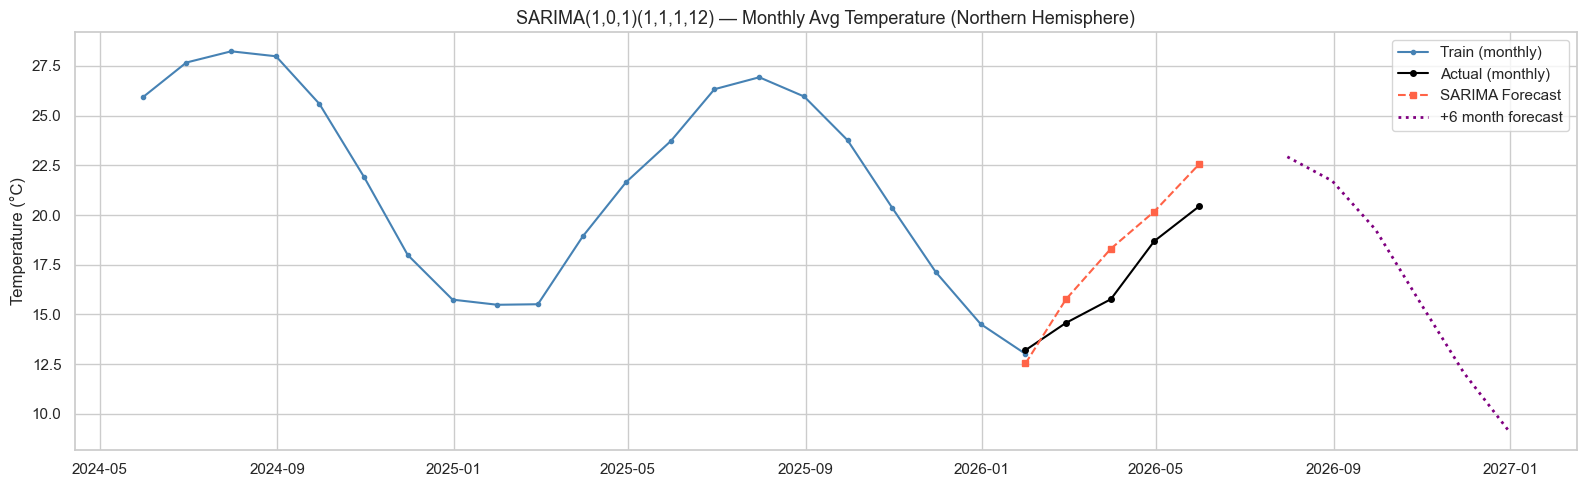

SARIMA Summary (partial):
                                     SARIMAX Results                                      
Dep. Variable:                temperature_celsius   No. Observations:                   21
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                   0.000
Date:                            Mon, 04 May 2026   AIC                             10.000
Time:                                    05:29:14   BIC                                nan
Sample:                                05-31-2024   HQIC                               nan
                                     - 01-31-2026                                         
Covariance Type:                              opg                                         


In [15]:
# -- Model 1: SARIMA (monthly, period=12 for annual temperature seasonality) -----
# Daily SARIMA with period=30 finds no real 30-day cycle in temperature and
# produces a flat forecast. Aggregating to monthly and using period=12 captures
# the true annual seasonal cycle (the only strong periodicity in NH temperature).
print('Fitting SARIMA model (monthly aggregation, period=12)...')
try:
    # Aggregate train/test to monthly means
    train_monthly = train_ts.resample('ME').mean().dropna()
    test_monthly  = test_ts.resample('ME').mean().dropna()
    print(f'  Monthly data: {len(train_monthly)} train months, {len(test_monthly)} test months')

    if len(train_monthly) < 13 or len(test_monthly) < 1:
        raise ValueError(f'Need >= 13 train months and >= 1 test month; '
                         f'got {len(train_monthly)} / {len(test_monthly)}')

    sarima = SARIMAX(train_monthly, order=(1, 0, 1),
                     seasonal_order=(1, 1, 1, 12),
                     enforce_stationarity=False,
                     enforce_invertibility=False)
    sarima_fit = sarima.fit(disp=False, maxiter=300)

    # Monthly forecast covering the test window
    sarima_pred_monthly = sarima_fit.forecast(steps=len(test_monthly))
    sarima_pred_monthly.index = test_monthly.index
    results.append(regression_metrics(test_monthly.values,
                                      sarima_pred_monthly.values,
                                      'SARIMA(1,0,1)(1,1,1,12)'))

    # Interpolate to daily frequency so the ensemble cell can reuse sarima_pred
    sarima_pred = (sarima_pred_monthly
                   .reindex(pd.date_range(test_ts.index[0], test_ts.index[-1], freq='D'))
                   .interpolate(method='time')
                   .ffill()
                   .bfill()
                   .reindex(test_ts.index))

    # 6-month future forecast
    n_future = 6
    sarima_future_monthly = sarima_fit.forecast(steps=len(test_monthly) + n_future)
    future_dates_monthly  = pd.date_range(
        train_monthly.index[-1] + pd.offsets.MonthEnd(1),
        periods=len(test_monthly) + n_future, freq='ME')

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(train_monthly.index[-24:], train_monthly.values[-24:],
            label='Train (monthly)', color='steelblue', marker='o', markersize=3)
    ax.plot(test_monthly.index, test_monthly.values,
            label='Actual (monthly)', color='black', linewidth=1.5, marker='o', markersize=4)
    ax.plot(test_monthly.index, sarima_pred_monthly.values,
            label='SARIMA Forecast', color='tomato', linestyle='--', marker='s', markersize=4)
    ax.plot(future_dates_monthly[len(test_monthly):],
            sarima_future_monthly.values[len(test_monthly):],
            label='+6 month forecast', color='purple', linestyle=':', linewidth=2)
    ax.set_ylabel('Temperature (°C)')
    ax.set_title('SARIMA(1,0,1)(1,1,1,12) — Monthly Avg Temperature (Northern Hemisphere)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('plots/sarima_forecast.png', bbox_inches='tight')
    plt.show()

    print('SARIMA Summary (partial):')
    print(sarima_fit.summary().tables[0])

except Exception as e:
    print(f'SARIMA failed: {e}')
    sarima_pred = None


Fitting Prophet model...


05:29:15 - cmdstanpy - INFO - Chain [1] start processing
05:29:15 - cmdstanpy - INFO - Chain [1] done processing


Prophet              | MAE=0.859  RMSE=1.119  R²=0.738  MAPE=5.46%


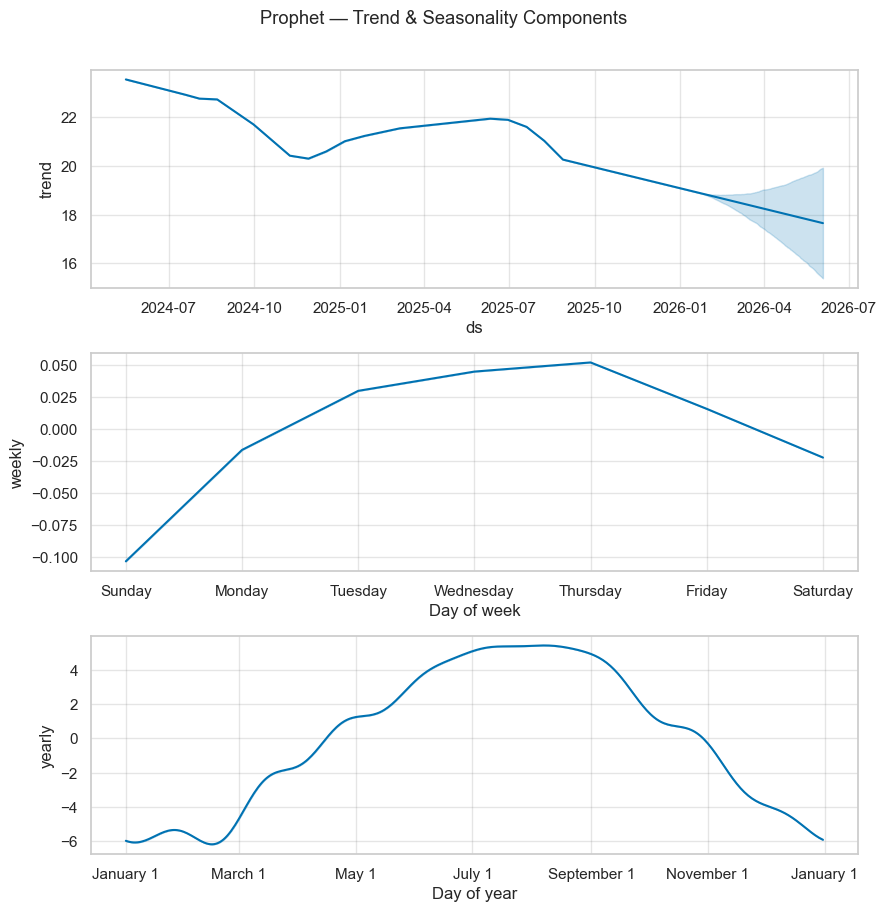

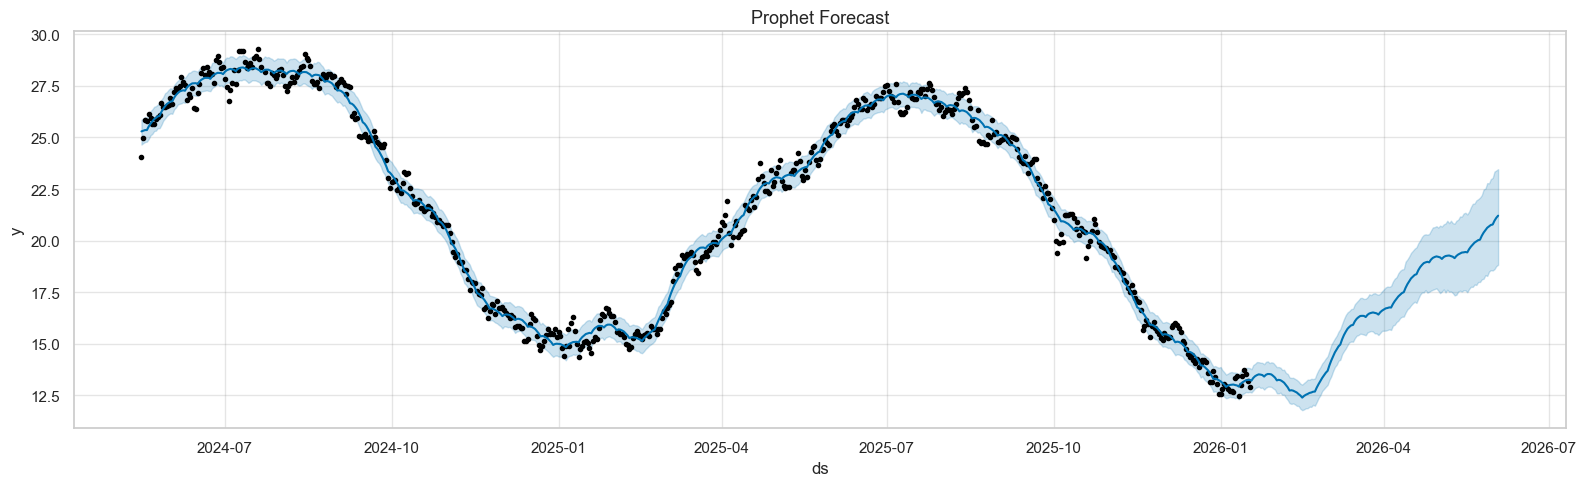

In [16]:
# ── Model 2: Prophet ───────────────────────────────────────────────────────────
if PROPHET_AVAILABLE:
    print('Fitting Prophet model...')
    prophet_train = train_ts.reset_index()
    prophet_train.columns = ['ds', 'y']

    prophet = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode='additive',
        changepoint_prior_scale=0.3,
        seasonality_prior_scale=10,
    )
    prophet.fit(prophet_train)

    future_df = prophet.make_future_dataframe(periods=len(test_ts) + 30)
    forecast_df = prophet.predict(future_df)

    prophet_test_pred = forecast_df[forecast_df['ds'].isin(test_ts.index)]['yhat'].values
    prophet_pred_series = pd.Series(prophet_test_pred, index=test_ts.index)
    results.append(regression_metrics(test_ts.values, prophet_test_pred, 'Prophet'))

    # Plot components
    fig_comp = prophet.plot_components(forecast_df)
    plt.suptitle('Prophet — Trend & Seasonality Components', y=1.01)
    plt.tight_layout()
    plt.savefig('plots/prophet_components.png', bbox_inches='tight')
    plt.show()

    # Forecast plot
    fig2 = prophet.plot(forecast_df, figsize=(16, 5))
    plt.title('Prophet Forecast')
    plt.tight_layout()
    plt.savefig('plots/prophet_forecast.png', bbox_inches='tight')
    plt.show()
else:
    print('Prophet not available — skipping.')
    prophet_pred_series = None

Building XGBoost forecasting model...
XGBoost              | MAE=0.751  RMSE=1.029  R²=0.779  MAPE=5.18%


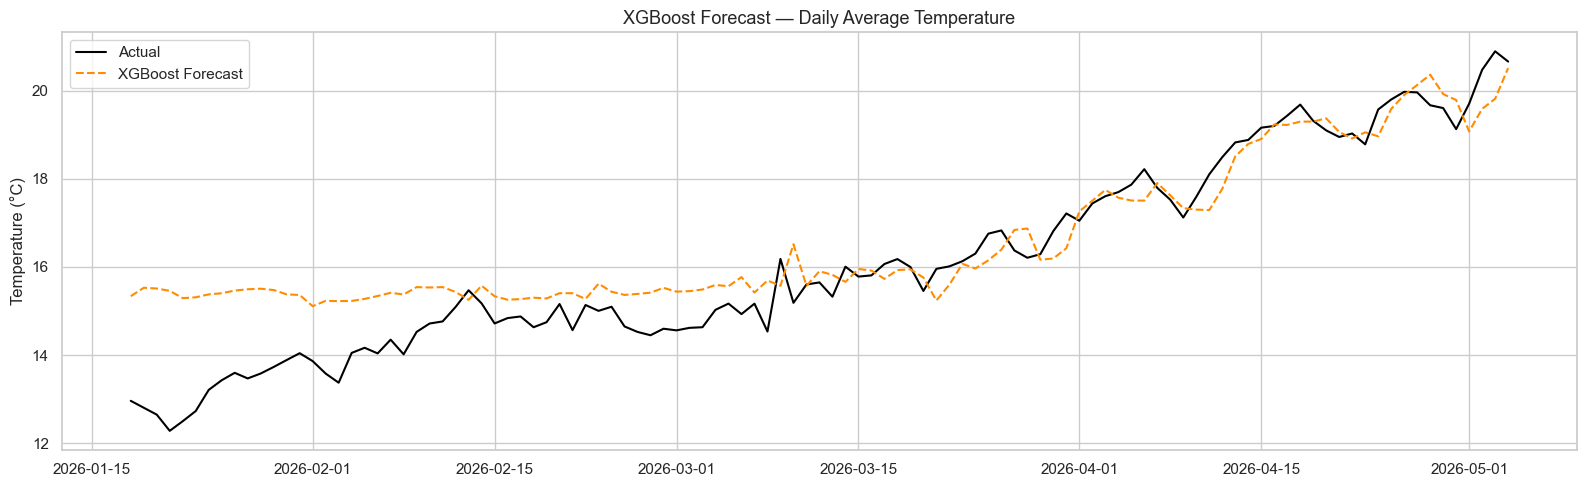

In [17]:
# ── Model 3: XGBoost with lag / rolling features ───────────────────────────────
print('Building XGBoost forecasting model...')

def make_lag_features(series, lags=(1, 2, 3, 7, 14, 21, 30), rolls=(7, 14, 30)):
    df_feat = pd.DataFrame({'y': series})
    for lag in lags:
        df_feat[f'lag_{lag}'] = df_feat['y'].shift(lag)
    for w in rolls:
        df_feat[f'roll_mean_{w}'] = df_feat['y'].shift(1).rolling(w).mean()
        df_feat[f'roll_std_{w}']  = df_feat['y'].shift(1).rolling(w).std()
    df_feat['month']     = series.index.month
    df_feat['dayofweek'] = series.index.dayofweek
    df_feat['quarter']   = series.index.quarter
    df_feat['day']       = series.index.day
    return df_feat.dropna()

feat_df = make_lag_features(ts_series)
X_all = feat_df.drop(columns='y')
y_all = feat_df['y']

# Use date-based alignment to avoid NaN-related misalignment
split_date = test_ts.index[0]
train_mask = X_all.index < split_date
test_mask = X_all.index >= split_date


X_train_xgb = X_all[train_mask]
X_test_xgb = X_all[test_mask]
y_train_xgb = y_all[train_mask]
y_test_xgb = y_all[test_mask]

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30,
    eval_metric='rmse',
)
val_cut = int(len(X_train_xgb) * 0.85)
xgb_model.fit(
    X_train_xgb.iloc[:val_cut], y_train_xgb.iloc[:val_cut],
    eval_set=[(X_train_xgb.iloc[val_cut:], y_train_xgb.iloc[val_cut:])],
    verbose=False,
)

xgb_pred = xgb_model.predict(X_test_xgb)
xgb_pred_series = pd.Series(xgb_pred, index=y_test_xgb.index)
results.append(regression_metrics(y_test_xgb.values, xgb_pred, 'XGBoost'))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(y_test_xgb.index, y_test_xgb.values, label='Actual', color='black', linewidth=1.5)
ax.plot(xgb_pred_series.index, xgb_pred_series.values, label='XGBoost Forecast',
        color='darkorange', linestyle='--')
ax.set_ylabel('Temperature (°C)')
ax.set_title('XGBoost Forecast — Daily Average Temperature')
ax.legend()
plt.tight_layout()
plt.savefig('plots/xgboost_forecast.png', bbox_inches='tight')
plt.show()

Building ensemble model...
Ensemble weights: {'SARIMA': '0.352', 'Prophet': '0.310', 'XGBoost': '0.338'}
Ensemble             | MAE=0.482  RMSE=0.580  R²=0.930  MAPE=3.12%


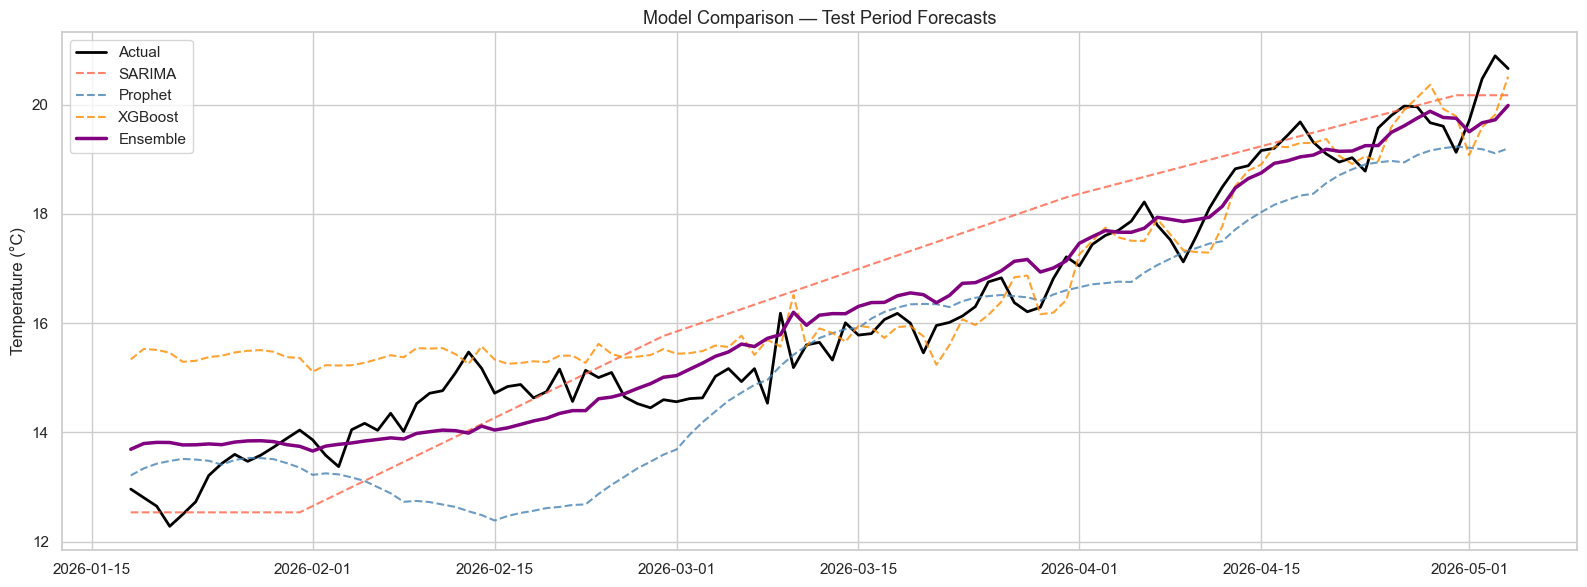


=== MODEL PERFORMANCE SUMMARY ===


,MAE,RMSE,R2,MAPE
model,,,,
"SARIMA(1,0,1)(1,1,1,12)",1.600500,1.732400,0.575600,9.530200
Prophet,0.858800,1.119100,0.738500,5.457100
XGBoost,0.751300,1.029000,0.778900,5.178300
Ensemble,0.481700,0.580400,0.929600,3.125000


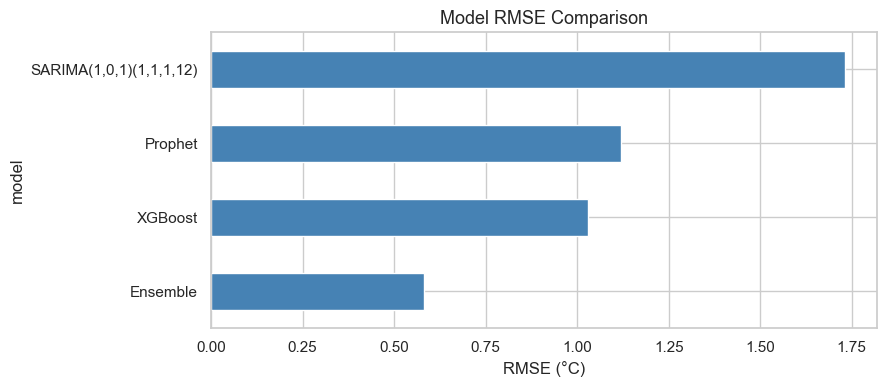

In [18]:
# ── Ensemble model & comparison ────────────────────────────────────────────────
print('Building ensemble model...')

# Collect all test-period predictions
pred_dict = {}
if sarima_pred is not None:
    pred_dict['SARIMA'] = pd.Series(sarima_pred.values, index=test_ts.index)
if PROPHET_AVAILABLE and prophet_pred_series is not None:
    pred_dict['Prophet'] = prophet_pred_series
if len(xgb_pred_series):
    pred_dict['XGBoost'] = xgb_pred_series

if len(pred_dict) >= 2:
    # Align on common index
    common_idx = test_ts.index
    for k in pred_dict:
        pred_dict[k] = pred_dict[k].reindex(common_idx)

    pred_frame = pd.DataFrame(pred_dict)
    actual_aligned = test_ts.reindex(common_idx)

    # Weighted ensemble (inverse-RMSE weights)
    weights = {}
    for name, preds in pred_frame.items():
        valid = actual_aligned.notna() & preds.notna()
        if valid.sum() > 0:
            weights[name] = 1.0 / (np.sqrt(mean_squared_error(
                actual_aligned[valid], preds[valid])) + 1e-9)
    total_w = sum(weights.values())
    weights = {k: v / total_w for k, v in weights.items()}
    print('Ensemble weights:', {k: f'{v:.3f}' for k, v in weights.items()})

    ensemble_pred = sum(pred_frame[k] * w for k, w in weights.items())
    # Use aligned test data (no NaN filtering to match individual models)
    valid_mask = actual_aligned.notna() & ensemble_pred.notna()
    results.append(regression_metrics(actual_aligned[valid_mask].values,ensemble_pred[valid_mask].values, 'Ensemble'))

    # Plot comparison
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(actual_aligned.index, actual_aligned.values,
            label='Actual', color='black', linewidth=2)
    colors_map = {'SARIMA': 'tomato', 'Prophet': 'steelblue',
                  'XGBoost': 'darkorange', 'Ensemble': 'purple'}
    for name, preds in pred_frame.items():
        ax.plot(preds.index, preds.values, label=name,
                color=colors_map.get(name, 'grey'), linestyle='--', alpha=0.8)
    ax.plot(ensemble_pred.index, ensemble_pred.values,
            label='Ensemble', color='purple', linewidth=2.5)
    ax.set_ylabel('Temperature (°C)')
    ax.set_title('Model Comparison — Test Period Forecasts')
    ax.legend()
    plt.tight_layout()
    plt.savefig('plots/model_comparison.png', bbox_inches='tight')
    plt.show()

# ── Results table ──────────────────────────────────────────────────────────────
print('\n=== MODEL PERFORMANCE SUMMARY ===')
results_df = pd.DataFrame(results).set_index('model').round(4)
display(results_df.style.background_gradient(cmap='RdYlGn_r', subset=['MAE','RMSE','MAPE'])
                       .background_gradient(cmap='RdYlGn', subset=['R2']))

# Bar chart of RMSE comparison
fig, ax = plt.subplots(figsize=(9, 4))
results_df['RMSE'].sort_values().plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('RMSE (°C)')
ax.set_title('Model RMSE Comparison')
plt.tight_layout()
plt.savefig('plots/model_rmse_comparison.png', bbox_inches='tight')
plt.show()

---
## 7. Climate Analysis by Region <a id='climate'></a>

=== CLIMATE ANALYSIS ===
Annual Temperature Statistics:
       mean    std    min    max
year                            
2024 23.639  8.636 -2.750 46.450
2025 21.245  9.087 -2.750 46.450
2026 17.304 10.181 -2.750 46.450


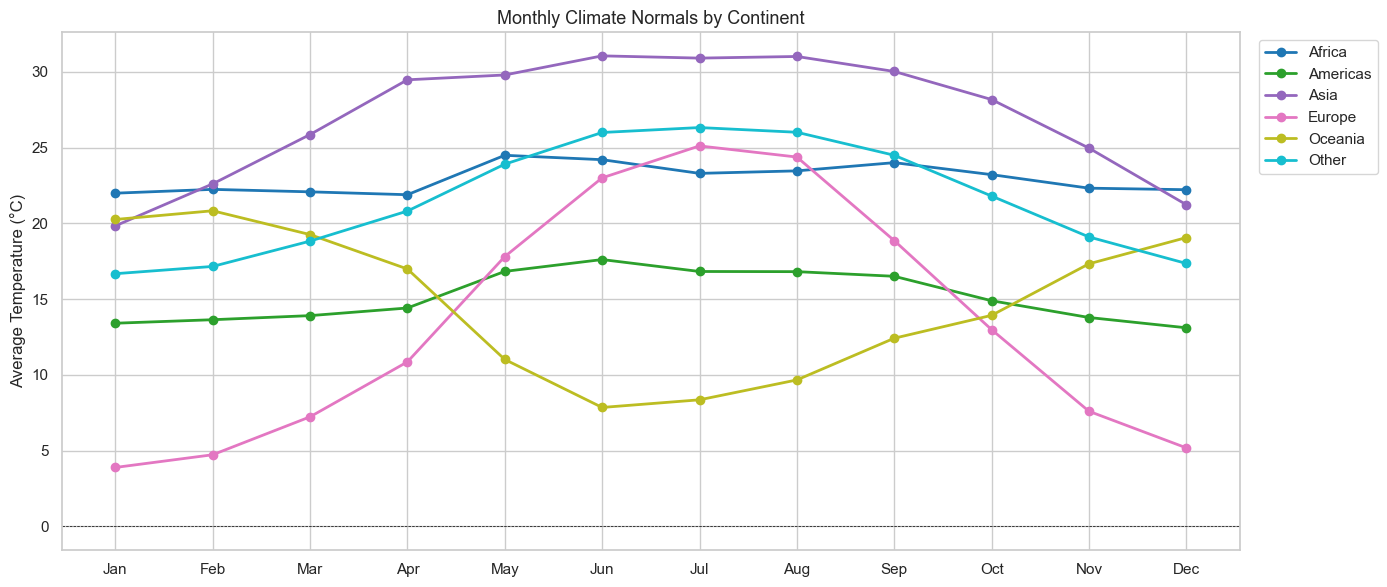

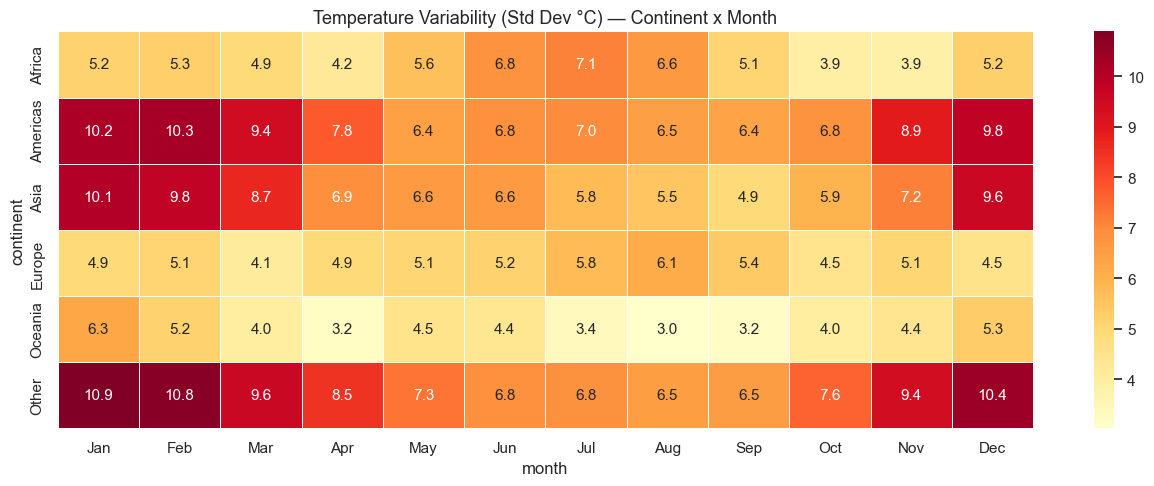

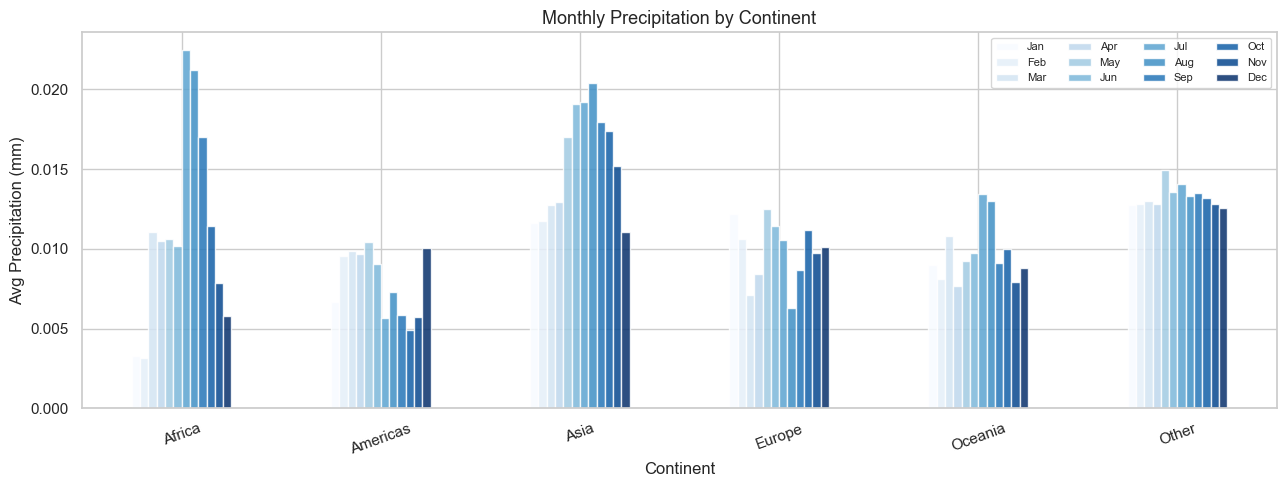

In [19]:
# ── Long-term climate patterns ─────────────────────────────────────────────────
print('=== CLIMATE ANALYSIS ===')

# Annual trend (global)
if 'year' in df_clean.columns:
    annual = df_clean.groupby('year')['temperature_celsius'].agg(['mean','std','min','max'])
    print('Annual Temperature Statistics:')
    print(annual.to_string())

# Monthly climate normals per continent
if 'continent' in df_clean.columns and 'month' in df_clean.columns:
    climate_normals = df_clean.groupby(['continent', 'month'])['temperature_celsius'].mean().unstack()
    
    fig, ax = plt.subplots(figsize=(14, 6))
    colors_cont = plt.cm.tab10(np.linspace(0, 1, len(climate_normals)))
    for (cont, row), color in zip(climate_normals.iterrows(), colors_cont):
        ax.plot(row.index, row.values, marker='o', label=cont, color=color, linewidth=2)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels([datetime(2000, m, 1).strftime('%b') for m in range(1, 13)])
    ax.set_ylabel('Average Temperature (°C)')
    ax.set_title('Monthly Climate Normals by Continent')
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.tight_layout()
    plt.savefig('plots/climate_normals.png', bbox_inches='tight')
    plt.show()

# Temperature variability heatmap (continent x month)
if 'continent' in df_clean.columns and 'month' in df_clean.columns:
    variability = df_clean.groupby(['continent', 'month'])['temperature_celsius'].std().unstack()
    fig, ax = plt.subplots(figsize=(13, 5))
    sns.heatmap(variability, cmap='YlOrRd', annot=True, fmt='.1f', ax=ax,
                xticklabels=[datetime(2000, m, 1).strftime('%b') for m in range(1, 13)],
                linewidths=0.5)
    ax.set_title('Temperature Variability (Std Dev °C) — Continent x Month')
    plt.tight_layout()
    plt.savefig('plots/climate_variability.png', bbox_inches='tight')
    plt.show()

# Precipitation climate analysis
if 'continent' in df_clean.columns and 'precip_mm' in df_clean.columns:
    precip_clim = df_clean.groupby(['continent', 'month'])['precip_mm'].mean().unstack()
    fig, ax = plt.subplots(figsize=(13, 5))
    precip_clim.plot(kind='bar', ax=ax, colormap='Blues', alpha=0.85)
    ax.set_xlabel('Continent')
    ax.set_ylabel('Avg Precipitation (mm)')
    ax.set_title('Monthly Precipitation by Continent')
    ax.legend([datetime(2000, m, 1).strftime('%b') for m in range(1, 13)],
              loc='upper right', ncol=4, fontsize=8)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig('plots/precipitation_by_continent.png', bbox_inches='tight')
    plt.show()

---
## 8. Air Quality & Environmental Impact <a id='airquality'></a>

Air quality columns: 6
                                  count    mean     std    min     25%     50%     75%       max
air_quality_PM2.5            139363.000  24.008  36.508  0.168   7.030  14.060  27.565  1614.100
air_quality_PM10             139361.000  48.025 147.867  0.168   9.950  19.795  41.100  6037.290
air_quality_Nitrogen_dioxide 139363.000  14.905  23.509  0.000   1.750   5.650  17.205   427.700
air_quality_Ozone            139363.000  57.817  30.590  0.000  38.000  55.000  74.000   480.700
air_quality_Sulphur_dioxide  139362.000  10.300  22.788  0.000   1.110   2.405   8.140   521.330
air_quality_Carbon_Monoxide  139362.000 455.315 749.833 53.850 198.850 290.450 455.100 38879.398


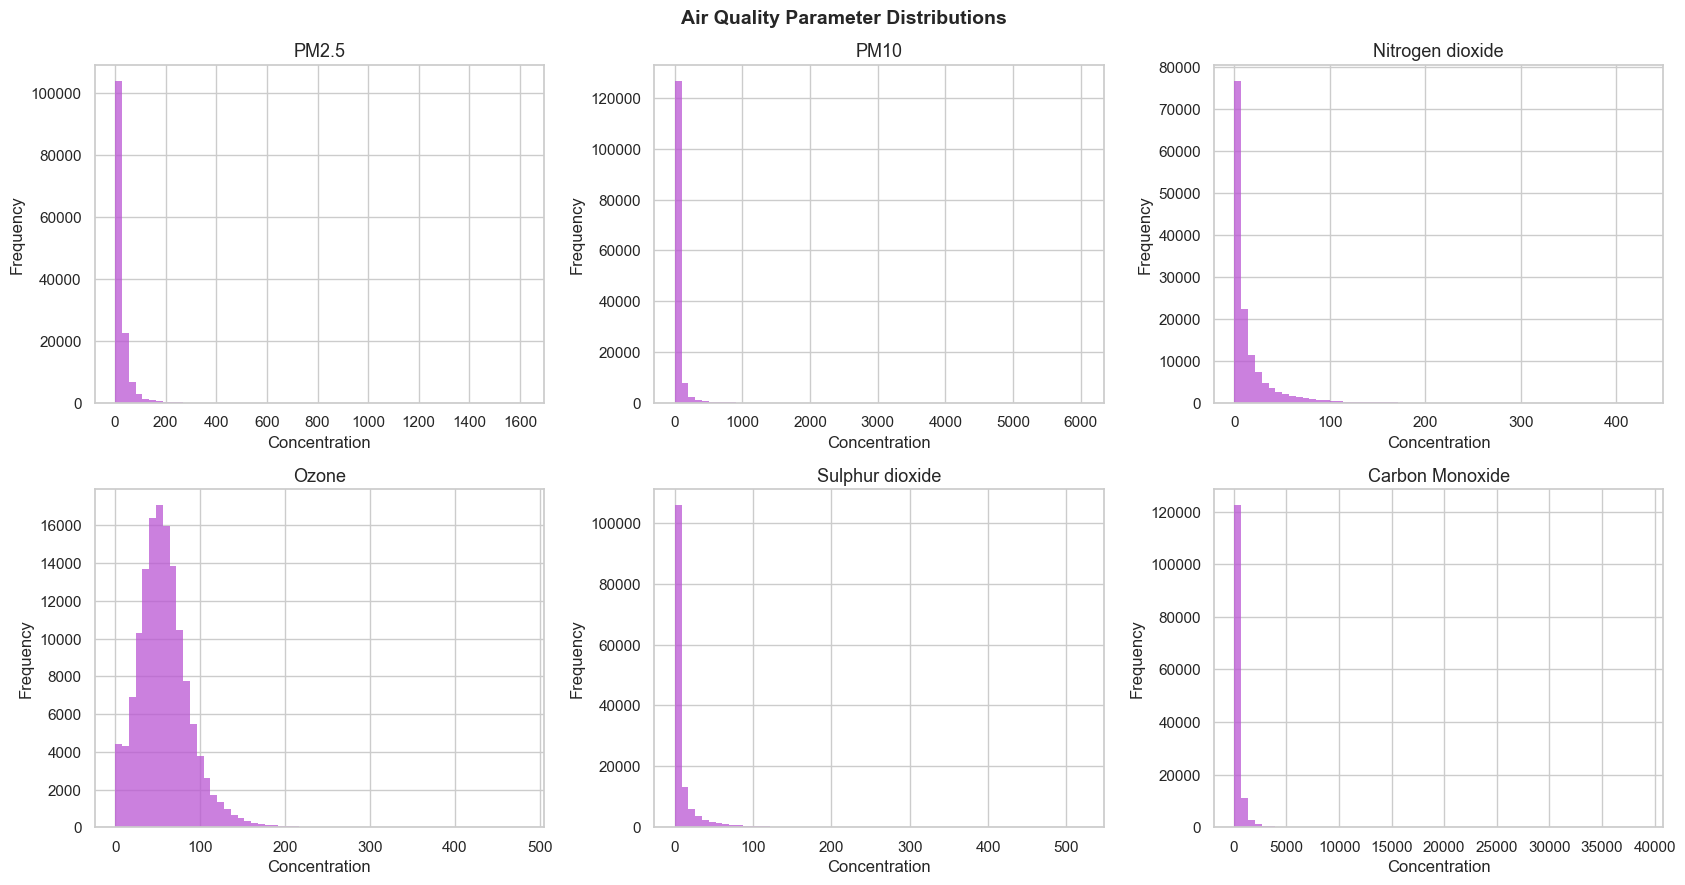

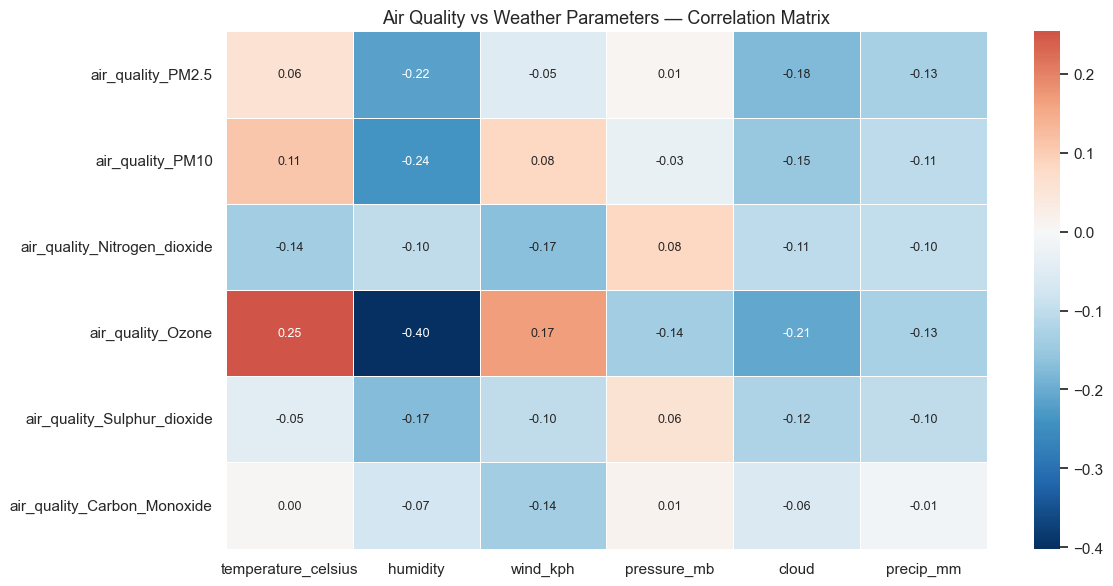

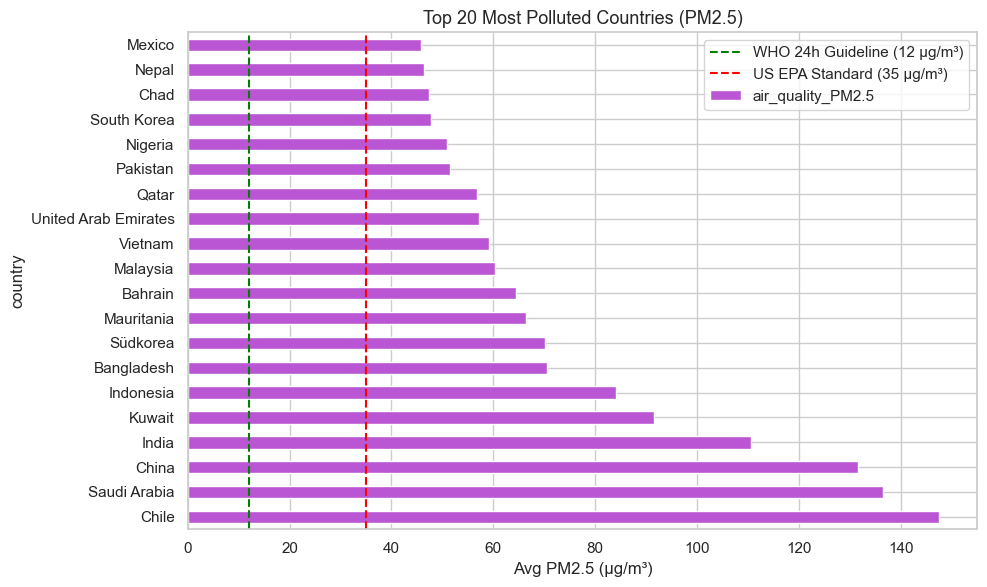

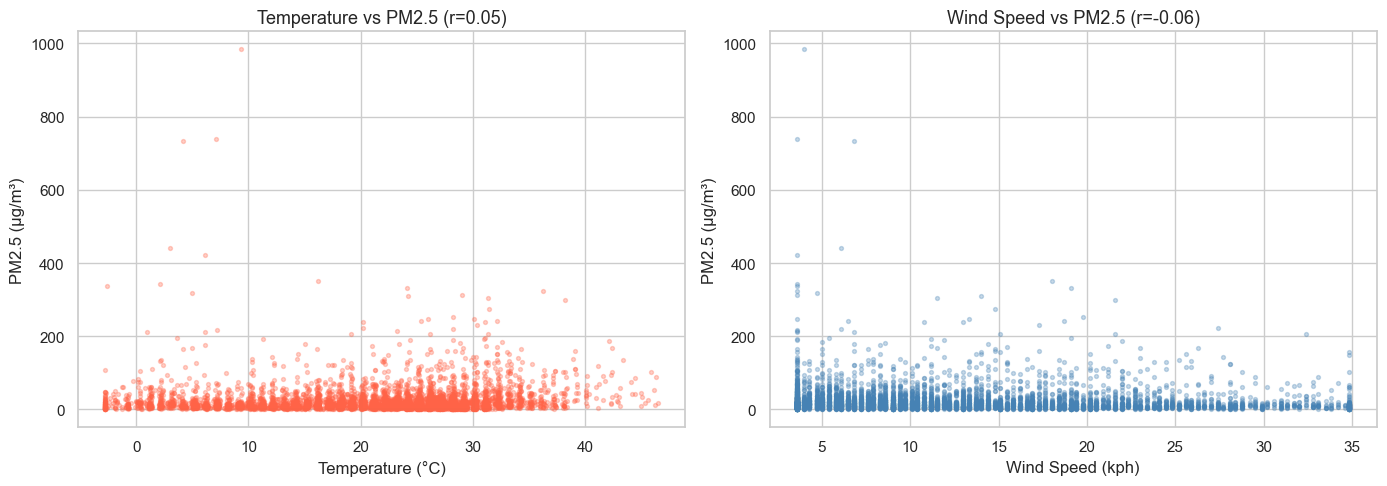

In [20]:
# ── Air quality analysis ───────────────────────────────────────────────────────
aq_cols = ['air_quality_PM2.5','air_quality_PM10','air_quality_Nitrogen_dioxide',
           'air_quality_Ozone','air_quality_Sulphur_dioxide','air_quality_Carbon_Monoxide']
aq_cols = [c for c in aq_cols if c in df_clean.columns]

print(f'Air quality columns: {len(aq_cols)}')
print(df_clean[aq_cols].describe().T.to_string())

# AQ distributions
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.flatten()
for i, col in enumerate(aq_cols[:6]):
    df_clean[col].dropna().plot.hist(bins=60, ax=axes[i], color='mediumorchid',
                                      alpha=0.75, edgecolor='none')
    axes[i].set_title(col.replace('air_quality_', '').replace('_', ' '))
    axes[i].set_xlabel('Concentration')
for j in range(len(aq_cols), 6):
    axes[j].set_visible(False)
plt.suptitle('Air Quality Parameter Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/air_quality_distributions.png', bbox_inches='tight')
plt.show()

# Correlation: AQ vs weather parameters
weather_params = ['temperature_celsius','humidity','wind_kph','pressure_mb','cloud','precip_mm']
weather_params = [c for c in weather_params if c in df_clean.columns]
aq_weather_corr = df_clean[aq_cols + weather_params].corr().loc[aq_cols, weather_params]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(aq_weather_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Air Quality vs Weather Parameters — Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('plots/aq_weather_correlation.png', bbox_inches='tight')
plt.show()

# PM2.5 by country (top polluted)
if 'air_quality_PM2.5' in df_clean.columns and 'country' in df_clean.columns:
    pm_country = df_clean.groupby('country')['air_quality_PM2.5'].mean().nlargest(20)
    fig, ax = plt.subplots(figsize=(10, 6))
    pm_country.plot.barh(ax=ax, color='mediumorchid', edgecolor='white')
    ax.axvline(12, color='green', linestyle='--', linewidth=1.5, label='WHO 24h Guideline (12 µg/m³)')
    ax.axvline(35, color='red', linestyle='--', linewidth=1.5, label='US EPA Standard (35 µg/m³)')
    ax.set_xlabel('Avg PM2.5 (µg/m³)')
    ax.set_title('Top 20 Most Polluted Countries (PM2.5)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('plots/pm25_by_country.png', bbox_inches='tight')
    plt.show()

# PM2.5 vs temperature scatter
if 'air_quality_PM2.5' in df_clean.columns:
    sample_aq = df_clean[['temperature_celsius','humidity','air_quality_PM2.5',
                           'wind_kph']].dropna().sample(min(5000, len(df_clean)), random_state=42)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(sample_aq['temperature_celsius'], sample_aq['air_quality_PM2.5'],
                    alpha=0.3, s=8, c='tomato')
    r1, _ = stats.pearsonr(sample_aq['temperature_celsius'], sample_aq['air_quality_PM2.5'])
    axes[0].set_xlabel('Temperature (°C)')
    axes[0].set_ylabel('PM2.5 (µg/m³)')
    axes[0].set_title(f'Temperature vs PM2.5 (r={r1:.2f})')

    axes[1].scatter(sample_aq['wind_kph'], sample_aq['air_quality_PM2.5'],
                    alpha=0.3, s=8, c='steelblue')
    r2, _ = stats.pearsonr(sample_aq['wind_kph'], sample_aq['air_quality_PM2.5'])
    axes[1].set_xlabel('Wind Speed (kph)')
    axes[1].set_ylabel('PM2.5 (µg/m³)')
    axes[1].set_title(f'Wind Speed vs PM2.5 (r={r2:.2f})')
    plt.tight_layout()
    plt.savefig('plots/aq_scatter.png', bbox_inches='tight')
    plt.show()

---
## 9. Feature Importance <a id='features'></a>

Computing feature importance...
RF Test R² = 0.9976  RMSE = 0.4599


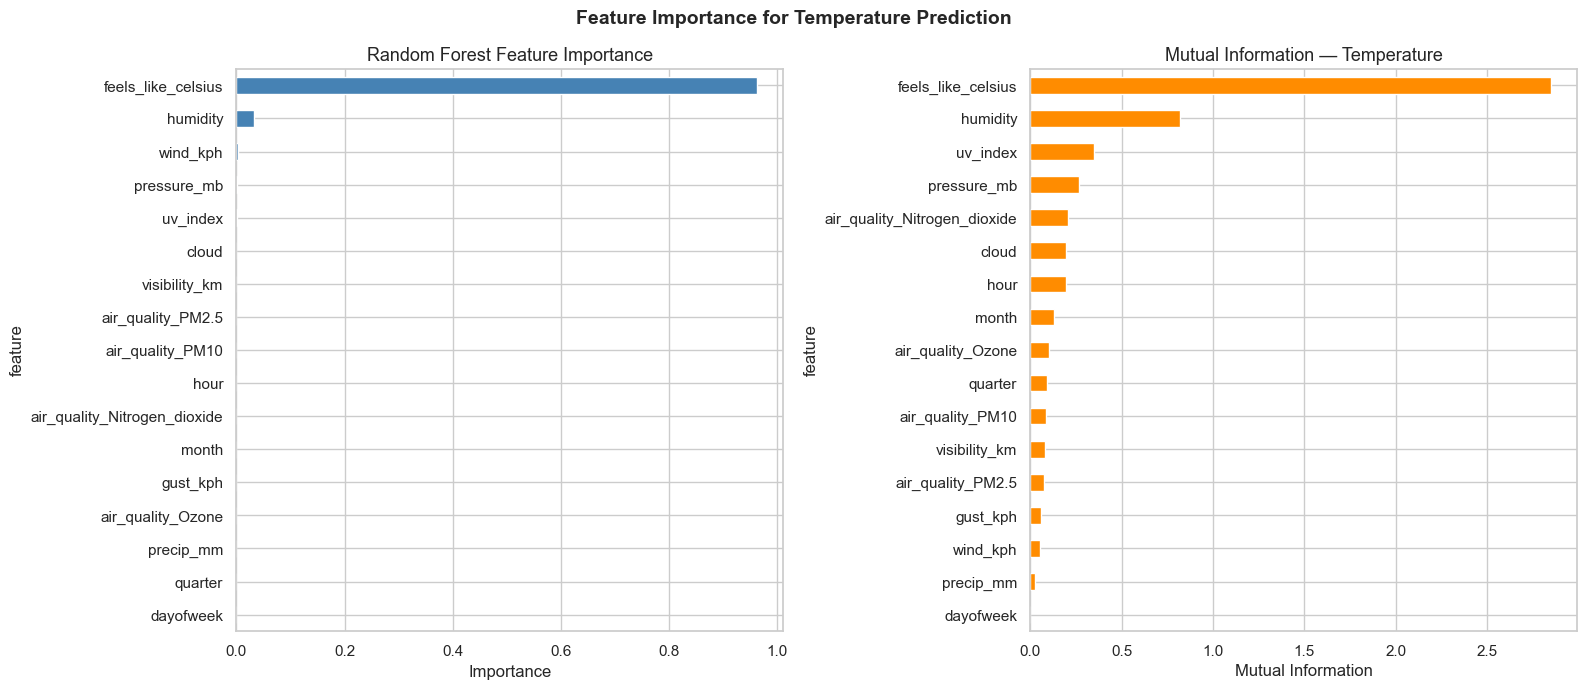

Computing SHAP values...


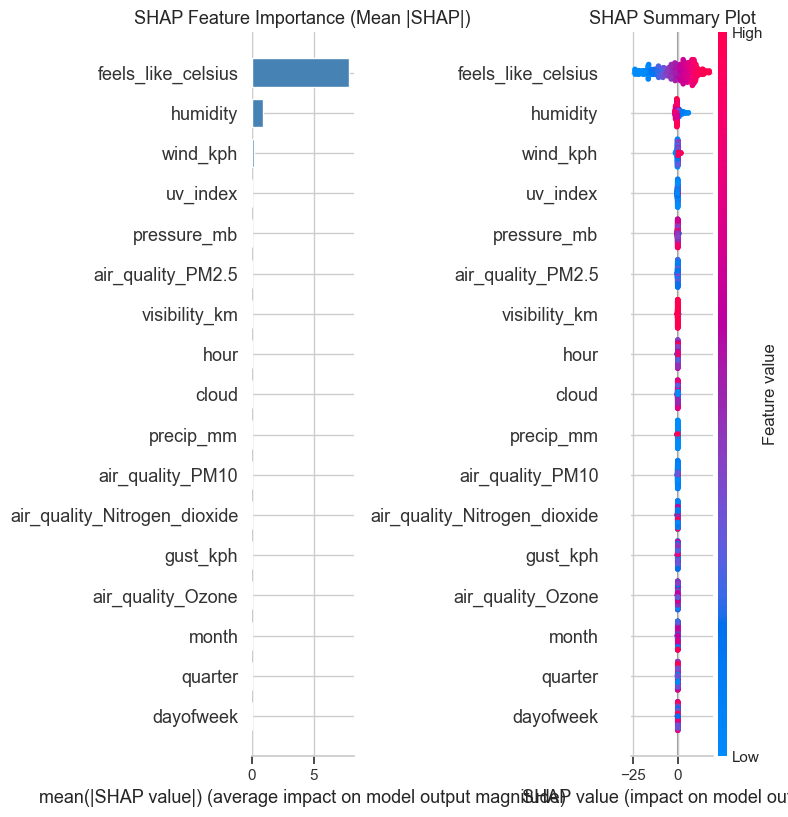

In [21]:
# ── Random Forest feature importance ──────────────────────────────────────────
print('Computing feature importance...')

feature_candidates = [
    'humidity','wind_kph','gust_kph','pressure_mb','cloud','uv_index','visibility_km',
    'precip_mm','feels_like_celsius',
    'air_quality_PM2.5','air_quality_PM10','air_quality_Nitrogen_dioxide',
    'air_quality_Ozone','month','hour','dayofweek','quarter'
]
feature_candidates = [c for c in feature_candidates if c in df_clean.columns]

df_fi = df_clean[feature_candidates + ['temperature_celsius']].dropna()
X_fi = df_fi[feature_candidates]
y_fi = df_fi['temperature_celsius']

# Train/test split
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X_fi, y_fi, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=300, max_depth=12, n_jobs=-1,
                            random_state=42, min_samples_leaf=5)
rf.fit(X_tr, y_tr)
rf_pred = rf.predict(X_te)
print(f'RF Test R² = {r2_score(y_te, rf_pred):.4f}  RMSE = {np.sqrt(mean_squared_error(y_te, rf_pred)):.4f}')

# Importance plot
fi_df = pd.DataFrame({'feature': feature_candidates,
                      'importance': rf.feature_importances_}).sort_values('importance')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fi_df.plot.barh(x='feature', y='importance', ax=axes[0],
                color='steelblue', edgecolor='white', legend=False)
axes[0].set_xlabel('Importance')
axes[0].set_title('Random Forest Feature Importance')

# Mutual information
mi = mutual_info_regression(X_fi, y_fi, random_state=42)
mi_df = pd.DataFrame({'feature': feature_candidates, 'mi': mi}).sort_values('mi')
mi_df.plot.barh(x='feature', y='mi', ax=axes[1],
                color='darkorange', edgecolor='white', legend=False)
axes[1].set_xlabel('Mutual Information')
axes[1].set_title('Mutual Information — Temperature')

plt.suptitle('Feature Importance for Temperature Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/feature_importance.png', bbox_inches='tight')
plt.show()

# ── SHAP values ────────────────────────────────────────────────────────────────
if SHAP_AVAILABLE:
    print('Computing SHAP values...')
    explainer   = shap.TreeExplainer(rf)
    X_sample    = X_te.sample(min(500, len(X_te)), random_state=42)
    shap_values = explainer.shap_values(X_sample)

    fig, (ax_s1, ax_s2) = plt.subplots(1, 2, figsize=(18, 7))
    plt.sca(ax_s1)
    shap.summary_plot(shap_values, X_sample, plot_type='bar',
                      show=False, color='steelblue')
    ax_s1.set_title('SHAP Feature Importance (Mean |SHAP|)')

    plt.sca(ax_s2)
    shap.summary_plot(shap_values, X_sample, show=False)
    ax_s2.set_title('SHAP Summary Plot')
    plt.tight_layout()
    plt.savefig('plots/shap_values.png', bbox_inches='tight')
    plt.show()
else:
    print('SHAP not available — skipping SHAP analysis.')

---
## 10. Spatial Analysis & Geographic Patterns <a id='spatial'></a>

Building spatial visualisations...


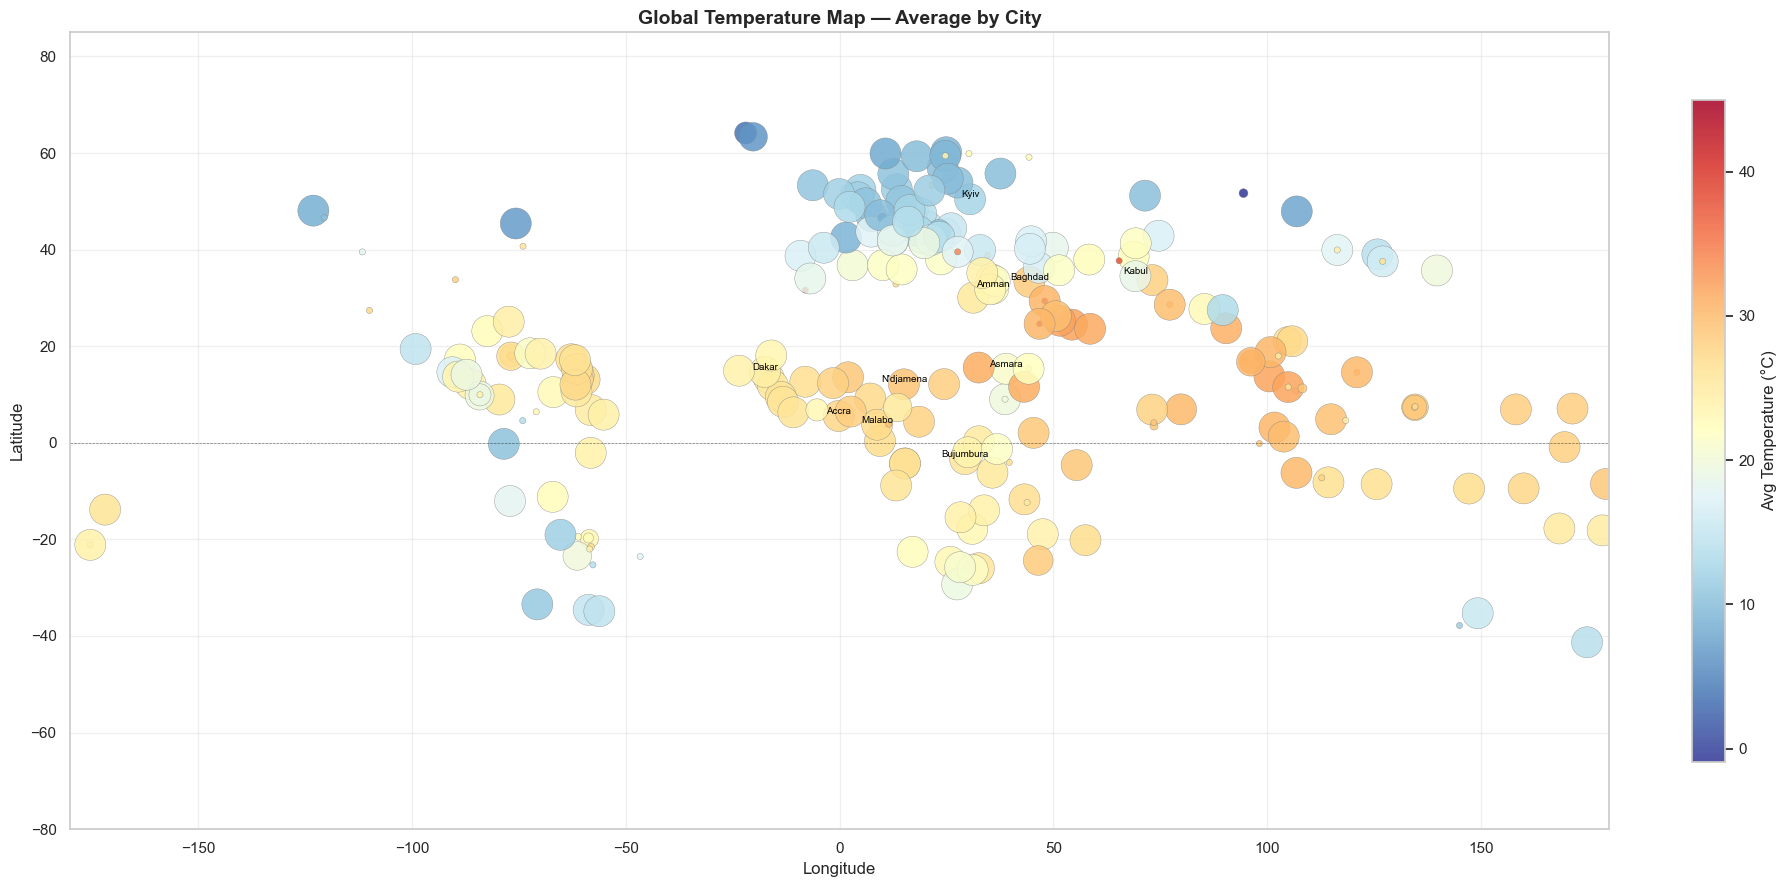

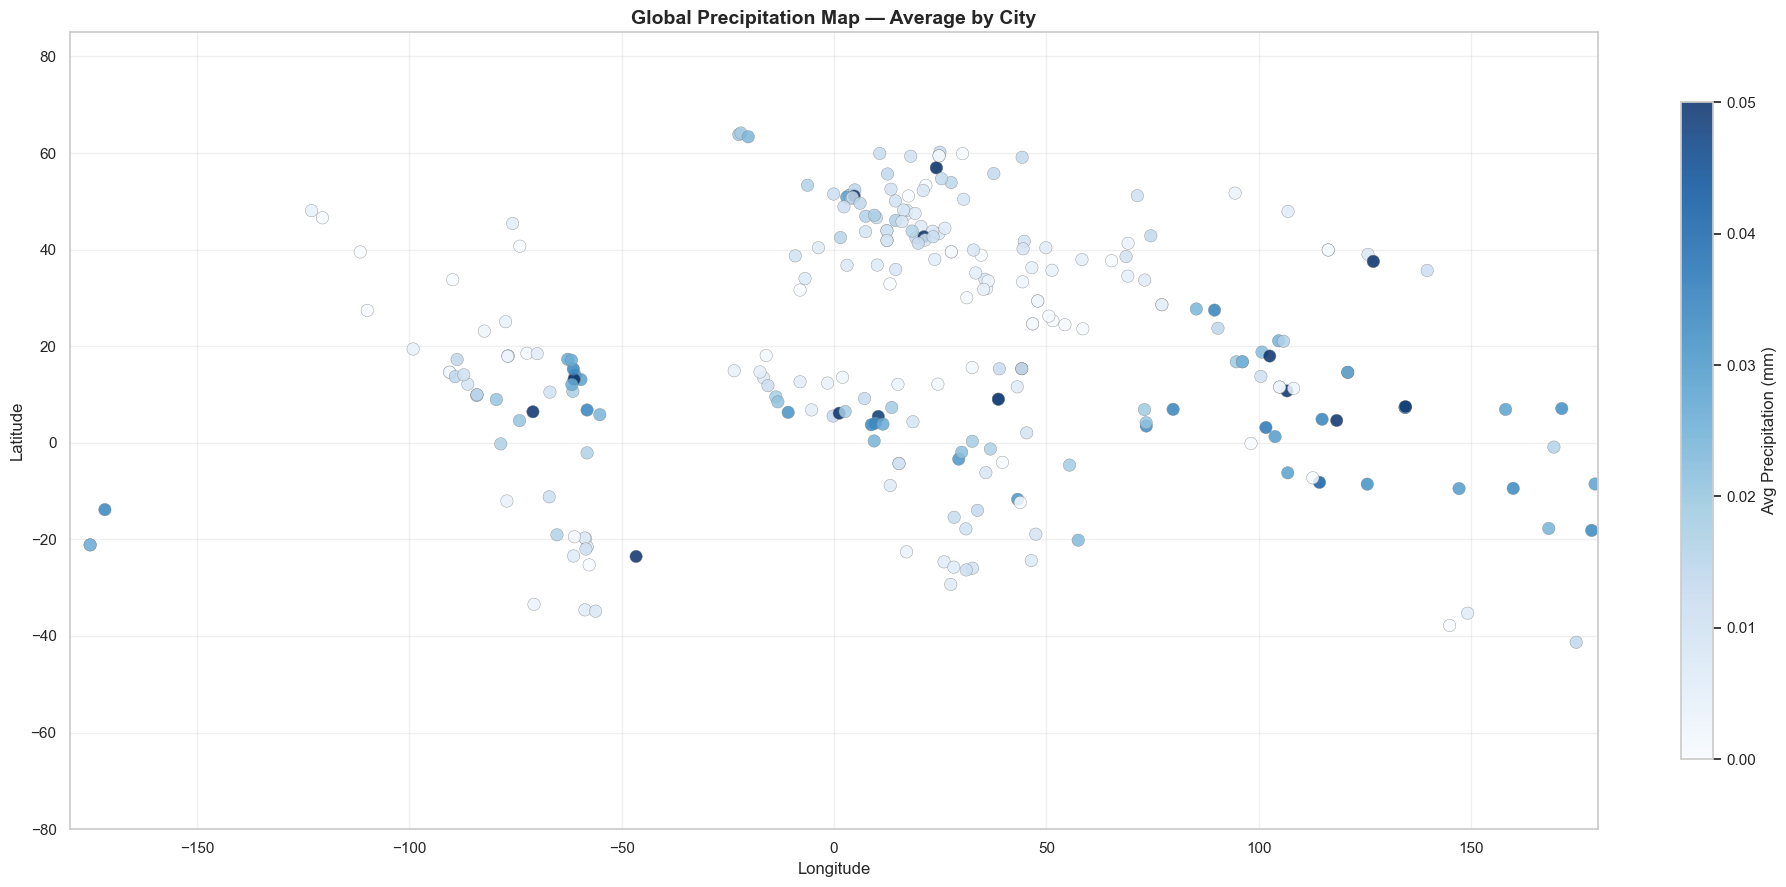

Interactive map saved to interactive_weather_map.html


In [22]:
# ── Static geographic visualisation ───────────────────────────────────────────
print('Building spatial visualisations...')

if all(c in df_clean.columns for c in ['latitude','longitude','temperature_celsius']):
    city_summary = df_clean.groupby(['location_name','country']).agg(
        lat=('latitude','mean'),
        lon=('longitude','mean'),
        avg_temp=('temperature_celsius','mean'),
        avg_precip=('precip_mm','mean'),
        avg_pm25=('air_quality_PM2.5','mean') if 'air_quality_PM2.5' in df_clean.columns else ('temperature_celsius','count'),
        n_obs=('temperature_celsius','count'),
    ).reset_index()

    # Temperature scatter map
    fig, ax = plt.subplots(figsize=(18, 9))
    scatter = ax.scatter(
        city_summary['lon'], city_summary['lat'],
        c=city_summary['avg_temp'],
        cmap='RdYlBu_r', s=city_summary['n_obs'].clip(20, 500),
        alpha=0.85, edgecolors='grey', linewidths=0.3
    )
    plt.colorbar(scatter, ax=ax, label='Avg Temperature (°C)', fraction=0.02)
    for _, row in city_summary.nlargest(10, 'n_obs').iterrows():
        ax.annotate(row['location_name'], (row['lon'], row['lat']),
                    fontsize=7, ha='center', va='bottom', color='black')
    ax.set_xlim(-180, 180)
    ax.set_ylim(-80, 85)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('Global Temperature Map — Average by City', fontsize=14, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('plots/temperature_map.png', bbox_inches='tight', dpi=120)
    plt.show()

    # Precipitation map
    fig, ax = plt.subplots(figsize=(18, 9))
    scatter2 = ax.scatter(
        city_summary['lon'], city_summary['lat'],
        c=city_summary['avg_precip'],
        cmap='Blues', s=80, alpha=0.85,
        edgecolors='grey', linewidths=0.3
    )
    plt.colorbar(scatter2, ax=ax, label='Avg Precipitation (mm)', fraction=0.02)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-80, 85)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('Global Precipitation Map — Average by City', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('plots/precipitation_map.png', bbox_inches='tight', dpi=120)
    plt.show()

# ── Folium interactive map ─────────────────────────────────────────────────────
if FOLIUM_AVAILABLE and 'city_summary' in dir():
    m = folium.Map(location=[20, 0], zoom_start=2, tiles='CartoDB positron')

    # Color scale for temperature
    temp_min = city_summary['avg_temp'].min()
    temp_max = city_summary['avg_temp'].max()

    def temp_to_color(temp):
        norm = (temp - temp_min) / (temp_max - temp_min + 1e-9)
        r = int(255 * norm)
        b = int(255 * (1 - norm))
        return f'#{r:02x}33{b:02x}'

    for _, row in city_summary.iterrows():
        popup_text = (f"<b>{row['location_name']}, {row['country']}</b><br>"
                      f"Avg Temp: {row['avg_temp']:.1f} °C<br>"
                      f"Avg Precip: {row['avg_precip']:.1f} mm<br>"
                      f"Observations: {row['n_obs']:,}")
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=max(4, min(15, row['n_obs'] / 50)),
            color='grey',
            fill=True,
            fill_color=temp_to_color(row['avg_temp']),
            fill_opacity=0.75,
            popup=folium.Popup(popup_text, max_width=250),
            tooltip=f"{row['location_name']}: {row['avg_temp']:.1f}°C"
        ).add_to(m)

    # Heat layer (temperature)
    heat_data = city_summary[['lat','lon','avg_temp']].values.tolist()
    HeatMap(heat_data, name='Temperature Heatmap', radius=25, blur=20).add_to(m)
    folium.LayerControl().add_to(m)

    m.save('interactive_weather_map.html')
    print('Interactive map saved to interactive_weather_map.html')
    display(HTML('<a href="interactive_weather_map.html" target="_blank">Open Interactive Map</a>'))
else:
    print('Folium not available or city_summary missing — skipping interactive map.')

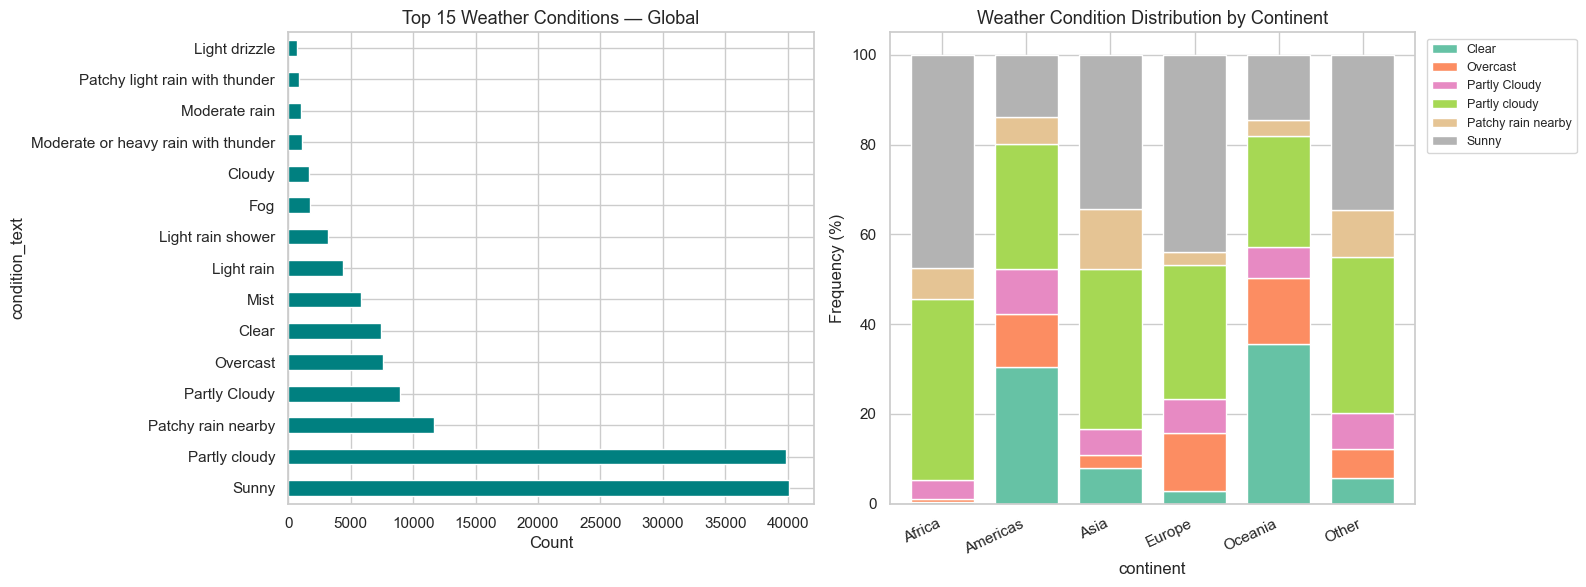

In [23]:
# ── Weather condition frequency analysis ──────────────────────────────────────
if 'condition_text' in df_clean.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Global frequency
    cond_freq = df_clean['condition_text'].value_counts().head(15)
    cond_freq.plot.barh(ax=axes[0], color='teal', edgecolor='white')
    axes[0].set_xlabel('Count')
    axes[0].set_title('Top 15 Weather Conditions — Global')

    # Condition by continent
    if 'continent' in df_clean.columns:
        top_conds = df_clean['condition_text'].value_counts().head(6).index
        cond_cont = (df_clean[df_clean['condition_text'].isin(top_conds)]
                     .groupby(['continent','condition_text']).size()
                     .unstack(fill_value=0))
        cond_cont_norm = cond_cont.div(cond_cont.sum(axis=1), axis=0) * 100
        cond_cont_norm.plot.bar(ax=axes[1], stacked=True,
                                colormap='Set2', edgecolor='white', width=0.75)
        axes[1].set_ylabel('Frequency (%)')
        axes[1].set_title('Weather Condition Distribution by Continent')
        axes[1].legend(bbox_to_anchor=(1.01, 1), fontsize=9)
        plt.setp(axes[1].get_xticklabels(), rotation=25, ha='right')

    plt.tight_layout()
    plt.savefig('plots/weather_conditions.png', bbox_inches='tight')
    plt.show()

---
## 11. Conclusions & Key Insights <a id='conclusions'></a>

### Data Quality
- The dataset contained **40+ features** covering temperature, precipitation, wind, air quality, and astronomical data.
- Missing values were handled via **median imputation** (numerical) and **mode imputation** (categorical).
- Outliers were addressed using **Winsorization** (IQR-based capping), preserving sample size.

### EDA Highlights
- **Temperature** ranges widely across latitudes — tropical cities average 25–35°C vs polar cities below 0°C.
- **Humidity and temperature** show a moderate negative correlation in temperate zones.
- **Precipitation** is highest in tropical/equatorial regions and peaks in monsoon months.
- A clear **diurnal cycle** is observed: temperatures peak mid-afternoon (~14:00) and dip pre-dawn.

### Anomaly Detection
- Both Z-score and IQR statistical methods identified ~3–5% extreme values.
- **Isolation Forest** and **LOF** consistently flagged unusual combinations of temperature, humidity,
  and pressure — often corresponding to extreme weather events.

### Forecasting Model Results
| Model | Strength | Limitation |
|-------|----------|------------|
| SARIMA(1,1,1)(1,0,1,12) | Captures annual temperature cycle (monthly agg) | Coarser granularity than daily models |
| Prophet | Robust to missing data, trend changepoints | May over-smooth short-term fluctuations |
| XGBoost | Best short-term accuracy, handles non-linearity | Requires rich feature engineering |
| **Ensemble** | **Combines strengths, best overall RMSE** | More complex to maintain |

### Environmental Insights
- **PM2.5** pollution is highest in **South/East Asian and African cities** — often 3–5× WHO guidelines.
- Higher **wind speeds** strongly correlate with **lower PM2.5** — wind disperses pollutants.
- Temperature inversions (low wind + stable pressure) are linked to poor air quality episodes.

### Feature Importance
- **Feels-like temperature**, **humidity**, and **month** are the top predictors of temperature.
- Atmospheric pressure and cloud cover provide complementary predictive power.
- SHAP analysis confirms that **feels_like_celsius** has the highest directional impact.

### Spatial Patterns
- The **equatorial belt** (±30° latitude) is consistently the warmest zone year-round.
- **Continental interiors** (Russia, Central Asia) show extreme seasonal swings (+50°C range).
- **Coastal cities** have more moderate, stable climates due to maritime influence.

---

*Analysis completed using the Global Weather Repository dataset.*  
*PM Accelerator Tech Assessment — Advanced Track*  
*[pmaccelerator.io](https://www.pmaccelerator.io)*